# Transcription Factor Project - Replogle et al. (2022) K562 Dataset Downstream Analysis
**Robin Anwyl, UCSD Subramaniam Lab**

**Goal:** Analyze the KOLF2.1J genome-wide Perturb-seq dataset from the Nourreddine et al. (2024) preprint to investigate the effects of transcription factor knockdowns (TF KDs). Compare to the Replogle et al. (2022) K562 genome-wide Perturb-seq dataset to explore cell-type-specific transcriptional regulatory networks in hiPSCs vs. chronic myeloid leukemia cells.

**Guiding Questions:** What do TF KD effects reveal about:
* the transcriptional regulatory network of hiPSCs and K562 cells?
* TF crosstalk and co-regulation?
* cell lineage?
* how TFs influence chromatin remodeling?

***

# Import statements

Using psp_env virtual env

In [1]:
import sys
import os
psp_root = "/home/ranwyl/KOLF2.1J_Perturbation_Cell_Atlas/"
if psp_root not in sys.path:
    sys.path.insert(0, psp_root)

import psp

In [2]:
import anndata as ad
import numpy as np
import pandas as pd
import decoupler as dc
import gseapy as gp
from tqdm_joblib import tqdm_joblib
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("white")
from biothings_client import get_client
import warnings
from contextlib import contextmanager

In [23]:
def validate_3_DGE_results_dfs(DGE_results_dfs: list[pd.DataFrame]
                               ) -> list[pd.DataFrame]:
    """
    Check that 3 DGE analysis results DFs have same rows and cols.
    """
    if not len(DGE_results_dfs) == 3:
        raise ValueError("Input must be list of 3 DataFrames")
    DGE_results_1 = DGE_results_dfs[0].sort_index()
    DGE_results_2 = DGE_results_dfs[1].sort_index()
    DGE_results_3 = DGE_results_dfs[2].sort_index()
    if not (DGE_results_1.index.equals(DGE_results_2.index) and 
            DGE_results_2.index.equals(DGE_results_3.index)):
        raise ValueError("DGE results DataFrames must have same index (genes)")
    if not ((set(DGE_results_1.columns) == set(DGE_results_2.columns)) &
            (set(DGE_results_2.columns) == set(DGE_results_3.columns))):
        raise ValueError("DGE results DataFrames must have same columns (KDs)")
    # Return DFs with sorted index
    return [DGE_results_1, DGE_results_2, DGE_results_3]

def build_3_run_DEGs_dict(DGE_results_dfs: list[pd.DataFrame],
                          p_threshold: float,
                          p_threshold_type: str="pvalue",
                          target_type: str="gRNA",
                          lfc_threshold: float = 0,
                          lfc_col: str = "log2FoldChange",
                          validate: bool=True,
                          remove_self_DEGs: bool=True,
                          ) -> dict[str, set[str]]:
    """
    For each KD, find genes that are DEGs of that KD (pass significance 
    and LFC thresholds) in at least 2 DGE analysis runs.
    If remove_self_DEGs is True, then Gene A is removed from the DEG list
    for Gene KD A and so on.
    """
    # Check for valid significance threshold
    if p_threshold_type not in ("pvalue", "padj"):
        raise ValueError("p_threshold_type must be 'pvalue' or 'padj'")
    # Check for valid target type
    if target_type not in ("gRNA", "gene_target"):
        raise ValueError("target_type must be 'gRNA' or 'gene_target'")
    # Check that 3 DGE analysis results DFs have same rows and cols
    if validate:
        DGE_results_dfs = validate_3_DGE_results_dfs(DGE_results_dfs)
    
    # Find genes that are DEGs of the same KD in at least 2 DGE runs
    DGE_results_1, DGE_results_2, DGE_results_3 = \
        DGE_results_dfs[0], DGE_results_dfs[1], DGE_results_dfs[2]
    if target_type == "gRNA":
        targets = {"_".join(col.split("_")[:2]) for col in DGE_results_1.columns}
    else:
        targets = {col.split("_")[0] for col in DGE_results_1.columns}
    targets = sorted(list(targets))
    DEGs_dict = dict()
    for target in targets:
        target_p_col = f"{target}_{p_threshold_type}"
        target_lfc_col = f"{target}_{lfc_col}"
        DEGs_run1 = set(
            DGE_results_1.loc[(DGE_results_1[target_p_col] < p_threshold) & 
            (abs(DGE_results_1[target_lfc_col]) > lfc_threshold)].index)
        DEGs_run2 = set(
            DGE_results_2.loc[(DGE_results_2[target_p_col] < p_threshold) & 
            (abs(DGE_results_2[target_lfc_col]) > lfc_threshold)].index)
        DEGs_run3 = set(
            DGE_results_3.loc[(DGE_results_3[target_p_col] < p_threshold) & 
            (abs(DGE_results_3[target_lfc_col]) > lfc_threshold)].index)                                 
        DEGs_at_least_2 = ((DEGs_run1 & DEGs_run2) | (DEGs_run2 & DEGs_run3) |
                           (DEGs_run1 & DEGs_run3))
        # Remove gene target from DEG list
        if remove_self_DEGs:
            self_gene = target if target_type == "gene_target" else target.split("_")[0]
            DEGs_at_least_2 = DEGs_at_least_2 - {self_gene}
        DEGs_dict[target] = DEGs_at_least_2
    return DEGs_dict

def build_3_run_wald_dict(DGE_results_dfs: list[pd.DataFrame],
                          wald_col: str="stat",
                          wald_abs_threshold: float = 1,
                          validate: bool = True,
                          kds: list[str] | set[str] | None = None,
                          remove_target_gene: bool=True,
                          ) -> dict[str, set[str]]:
    """
    For each KD, find genes that have |Wald| > wald_abs_threshold 
    in at least 2 DGE analysis runs.
    """
    # Check that 3 DGE analysis results DFs have same rows and cols
    if validate:
        DGE_results_dfs = validate_3_DGE_results_dfs(DGE_results_dfs)

    # For each KD, find genes with |Wald| > 1 in at least 2 runs
    DGE_results_1, DGE_results_2, DGE_results_3 = \
        DGE_results_dfs[0], DGE_results_dfs[1], DGE_results_dfs[2]
    if kds is None:
        kds = {col.split("_")[0] for col in DGE_results_1.columns}
    kds = sorted(list(kds))
    wald_dict = dict()
    for kd in kds:
        kd_wald_col = f"{kd}_{wald_col}"
        wald_genes_run1 = set(DGE_results_1.loc[
            abs(DGE_results_1[kd_wald_col]) > wald_abs_threshold].index)
        wald_genes_run2 = set(DGE_results_2.loc[
            abs(DGE_results_2[kd_wald_col]) > wald_abs_threshold].index)
        wald_genes_run3 = set(DGE_results_3.loc[
            abs(DGE_results_3[kd_wald_col]) > wald_abs_threshold].index)                                
        wald_genes_at_least_2 = ((wald_genes_run1 & wald_genes_run2) | 
                                 (wald_genes_run2 & wald_genes_run3) |
                                 (wald_genes_run1 & wald_genes_run3))
        # Remove target gene from gene list
        if remove_target_gene:
            wald_genes_at_least_2 = wald_genes_at_least_2 - {kd}
        wald_dict[kd] = wald_genes_at_least_2
    return wald_dict

def build_3_run_n_DEGs_df(DEGs_dict: dict[str, set[str]]
                          ) -> pd.DataFrame:
    """
    From a dict of DEGs for each KD, build a DataFrame reporting
    the number of DEGs per KD.
    """
    kds = list(DEGs_dict.keys())
    n_DEGs = [len(DEGs_dict[kd]) for kd in kds]
    n_DEGs_df = pd.DataFrame(n_DEGs, index=kds, columns=["n_DEGs"])
    n_DEGs_df = n_DEGs_df.sort_values(by="n_DEGs", ascending=False)
    return n_DEGs_df

def build_cluster_DEGs_dict(DEGs_dict: dict[str, set[str]],
                            cluster_df: pd.DataFrame
                            ) -> dict[int, set[str]]:
    """
    Build dict of DEGs per cluster.
    """
    cluster_kd_dict = {
        int(cl): list(cluster_df[cl][cluster_df[cl].notna()])
        for cl in cluster_df.columns
    }
    cluster_DEGs_dict = {
        cl: set().union(*[DEGs_dict[kd] for kd in cluster_kd_dict[cl]])
        for cl in cluster_kd_dict
    }
    return cluster_DEGs_dict

def plot_n_DEGs_per_cluster(cluster_DEGs_dict: dict[int, set[str]],
                            title: str, 
                            figsize: tuple[int, int] = (6,3), 
                            xlabel: str="Cluster", 
                            xtick_rotation: int=90,
                            ymax: int | None = None,
                            color: str = "tab:blue"):
    """
    Given a dict of DEGs per cluster, plot number of DEGs per cluster.
    """
    clusters = [f"CL{str(cl)}" for cl in cluster_DEGs_dict.keys()]
    n_DEGs = [len(cluster_DEGs_dict[cl]) for cl in cluster_DEGs_dict.keys()]
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(x=clusters, y=n_DEGs, ax=ax, color=color)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("# DEGs per cluster")
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f', padding=2, fontsize=10, rotation=90)
    plt.xticks(fontsize=11, rotation=xtick_rotation)
    plt.yticks(fontsize=11)
    ax.yaxis.set_major_formatter('{x:.0f}')
    if ymax:
        ax.set_ylim(0, ymax)
    ax.set_title(title)

def build_strong_kds_per_cluster_df(DEGs_dict: dict[str, set[str]],
                                    cluster_df: pd.DataFrame,
                                    DEG_threshold_inclusive: int=10,
                                    kd_label: str="KD"):
    kds = list(DEGs_dict.keys())
    n_DEGs = [len(DEGs_dict[kd]) for kd in kds]
    n_DEGs_df = pd.DataFrame(n_DEGs, index=kds, columns=["n_DEGs"])
    n_DEGs_df = n_DEGs_df[n_DEGs_df["n_DEGs"] >= DEG_threshold_inclusive]
    cluster_kd_dict = {
        int(cl): list(cluster_df[cl][cluster_df[cl].notna()])
        for cl in cluster_df.columns
    }
    cluster_strong_kd_dict = {
        cl: [kd for kd in cluster_kd_dict[cl] if kd in n_DEGs_df.index]
        for cl in cluster_kd_dict
    }
    strong_kds_per_cluster_df = \
        pd.DataFrame({f"{kd_label}s w/ ≥{DEG_threshold_inclusive} DEGs per cluster": 
                      [len(cluster_strong_kd_dict[cl]) 
                       for cl in cluster_strong_kd_dict]},
                       index=[cl for cl in cluster_kd_dict])
    return strong_kds_per_cluster_df

def plot_n_kds_per_cluster(
        cluster_df: pd.DataFrame, 
        title: str,
        kd_label: str="KD",
        figsize: tuple[int, int] = (6,3), 
        xlabel: str="Cluster", 
        xtick_rotation: int=90,
        ymax: int | None = None,
        color: str = "tab:blue"):
    """
    Plot number of perturbations per cluster.
    """
    sns.set_style("whitegrid")
    n_kds_per_cluster = cluster_df.count()
    xvals = [f"CL{str(i)}" for i in range(len(n_kds_per_cluster))]
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(x=xvals, y=n_kds_per_cluster, ax=ax,
                color=color)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(f"# {kd_label}s in cluster")
    plt.xticks(fontsize=11, rotation=xtick_rotation)
    plt.yticks(fontsize=11)
    ax.yaxis.set_major_formatter('{x:.0f}')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f', padding=2, fontsize=10)
    if ymax:
        ax.set_ylim(0, ymax)
    ax.set_title(title)

# Read in data

In [ ]:
# filepath = "/home/ranwyl/data_tf_project/K562_QC_NTC_norm_KDefficiency_Etest_gRNA_filtered.h5ad"
# adata_k562 = psp.utils.read_anndata(filepath)
# adata_k562

In [4]:
filepath1 = "/home/ranwyl/results_tf_project/K562_DE_results_KD_shrunk_seed42_5-14-26.pkl"
de_results_k562_1 = pd.read_pickle(filepath1)
filepath2 = "/home/ranwyl/results_tf_project/K562_DE_results_KD_shrunk_seed12_5-14-26.pkl"
de_results_k562_2 = pd.read_pickle(filepath2)
filepath3 = "/home/ranwyl/results_tf_project/K562_DE_results_KD_shrunk_seed123_5-14-26.pkl"
de_results_k562_3 = pd.read_pickle(filepath3)
de_results_k562 = [de_results_k562_1, de_results_k562_2, de_results_k562_3]

In [5]:
kd_deg_dict_k562 = build_3_run_DEGs_dict(de_results_k562, p_threshold=0.005,
                                         p_threshold_type="pvalue", target_type="gene_target",
                                         remove_self_DEGs=True)
n_degs_df_k562 = build_3_run_n_DEGs_df(kd_deg_dict_k562)
n_degs_df_k562[0:20]

,n_DEGs
DNMT1,405
CXXC1,164
MAX,149
MYB,140
TFDP1,127
TBX1,119
ETV4,106
NKX6-1,103
SETDB1,93
ZBTB17,76


In [6]:
kd_subset = set(n_degs_df_k562[n_degs_df_k562['n_DEGs'] > 4].index)
print(f"{len(kd_subset)} out of {len(n_degs_df_k562)} TF KDs have >4 DEGs (excluding self-DEGs)")

429 out of 916 TF KDs have >4 DEGs (excluding self-DEGs)


In [7]:
kd_wald_dict_k562 = build_3_run_wald_dict(de_results_k562, kds=kd_subset, remove_target_gene=True)

In [8]:
leiden_clusters_filepath = \
    "/home/ranwyl/output_files_tf_project/K562_leiden_clusters_spectral25-mde7-knn6-repulsive5_6-4-26.csv"
leiden_clusters_k562 = pd.read_csv(leiden_clusters_filepath, header=0, index_col=0)
leiden_clusters_k562.head(3)

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,ALX3,CTCFL,ARID3B,ADNP,ARID5B,ARID2,DLX4,ATF1,FOXI3,CHAMP1,...,AHRR,FOXO1,ETV4,AKAP8L,AEBP1,FIGLA,ERG,EVX2,CREBL2,CXXC4
1,BAZ2B,FEZF1,BATF,ADNP2,CPEB1,ATMIN,EMX1,DR1,IKZF1,FBXL19,...,HES4,HOXA9,HMBOX1,CARF,CLOCK,FOXL2,GMEB1,FOXG1,FLI1,DLX2
2,FOS,HEY1,CEBPB,BHLHE40,CXXC1,CAMTA2,FOXM1,DRAP1,KIN,FOXN1,...,HOXA10,IKZF4,MSANTD4,E2F8,RFX5,HIC2,HOXB6,IKZF2,MTF1,TBX18


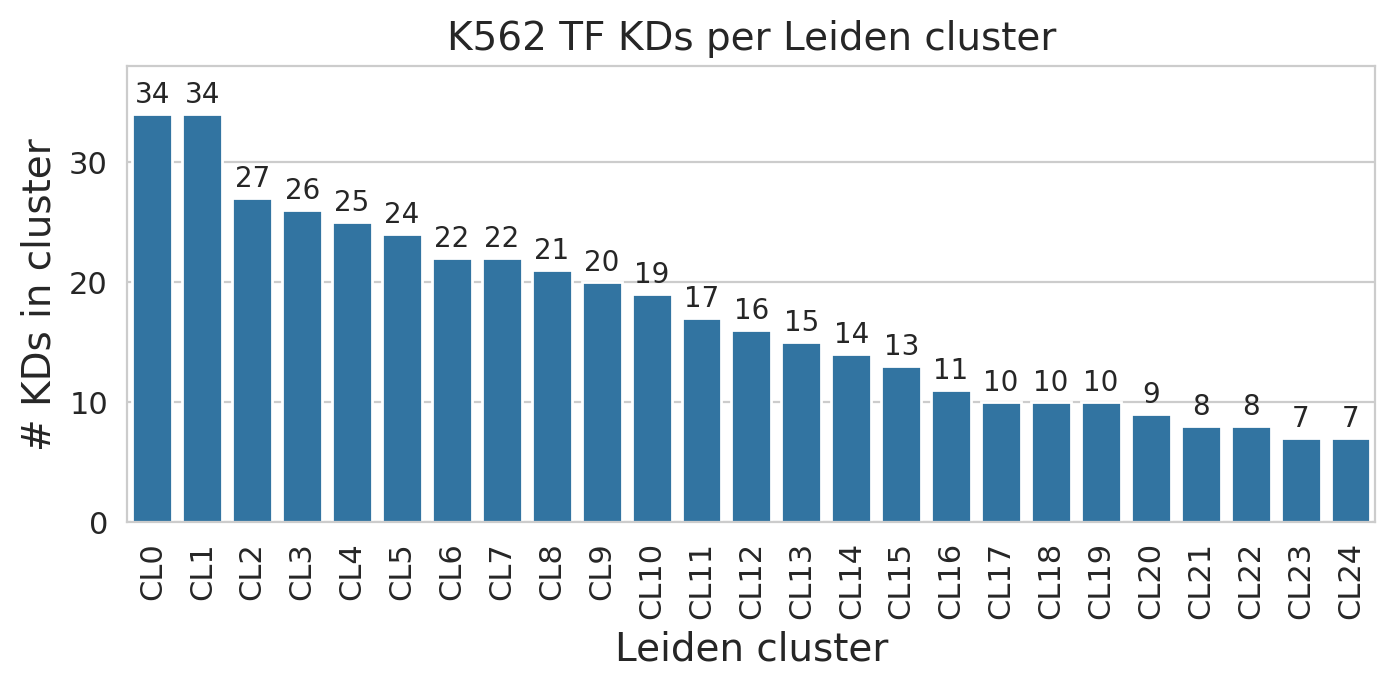

In [ ]:
title = "K562 TF KDs per Leiden cluster"
_ = plot_n_kds_per_cluster(leiden_clusters_k562, title=title, ymax=38,
                           xlabel="Leiden cluster", figsize=(8,3))

In [10]:
cluster_deg_dict_k562 = build_cluster_DEGs_dict(kd_deg_dict_k562,
                                                leiden_clusters_k562)

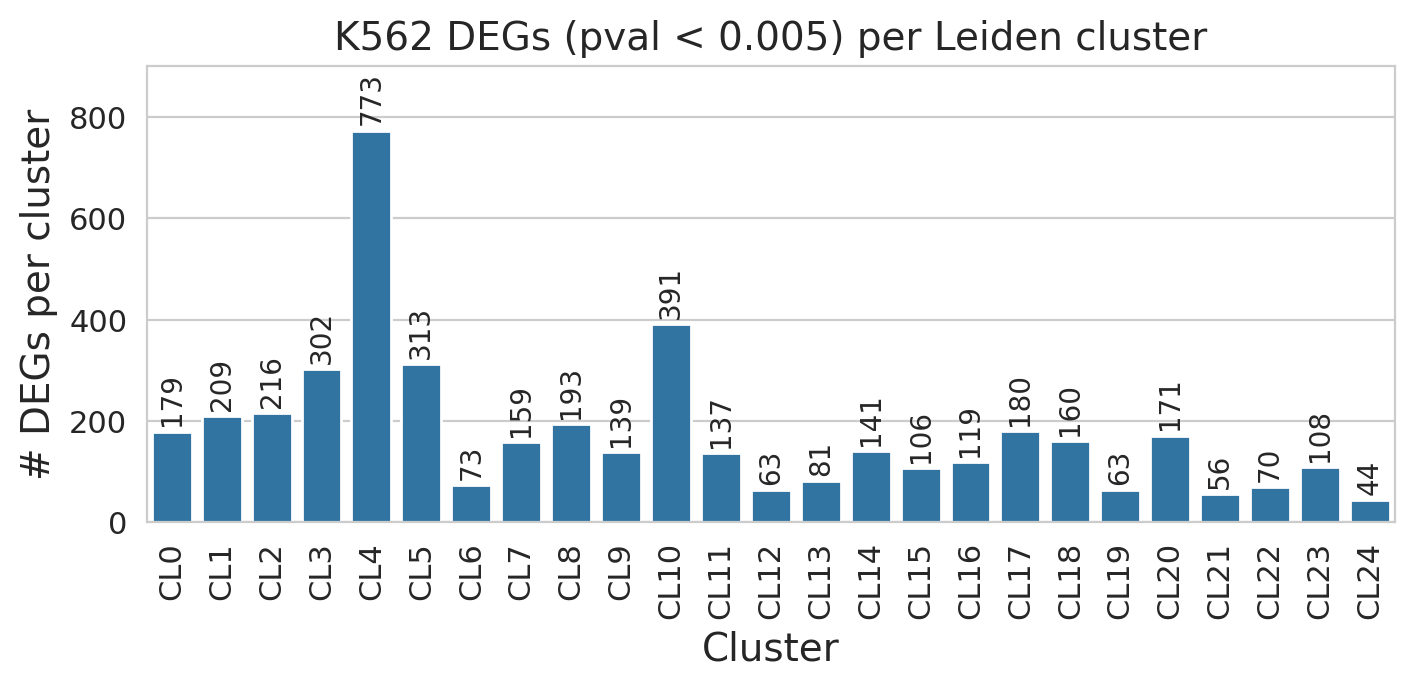

In [27]:
_ = plot_n_DEGs_per_cluster(cluster_deg_dict_k562,
                            title="K562 DEGs (pval < 0.005) per Leiden cluster",
                            figsize=(8,3), ymax=900)

In [28]:
strong_kds_per_cluster_df_k562 = \
    build_strong_kds_per_cluster_df(kd_deg_dict_k562, leiden_clusters_k562, kd_label="TF KD")
strong_kds_per_cluster_df_k562

,TF KDs w/ ≥10 DEGs per cluster
0,10
1,7
2,12
3,18
4,15
5,19
6,2
7,9
8,11
9,8


In [32]:
print("Clusters with ≥10 TF KDs: 20")
print("Clusters with <10 TF KDs: 5")
print()

print(f"Clusters with ≥3 strong TF KDs: "
      f"{len(strong_kds_per_cluster_df_k562[strong_kds_per_cluster_df_k562['TF KDs w/ ≥10 DEGs per cluster'] >= 3])}")
print(f"Clusters with <3 strong TF KDs: "
      f"{len(strong_kds_per_cluster_df_k562[strong_kds_per_cluster_df_k562['TF KDs w/ ≥10 DEGs per cluster'] < 3])}")

Clusters with ≥10 TF KDs: 20
Clusters with <10 TF KDs: 5

Clusters with ≥3 strong TF KDs: 20
Clusters with <3 strong TF KDs: 5


# Filter Entrez genes for Pathview (using DGE results)

In [ ]:
filepath1 = "/home/ranwyl/results_tf_project/K562_DE_results_KD_shrunk_seed42_5-14-26.pkl"
de_results_k562_1 = pd.read_pickle(filepath1)
filepath2 = "/home/ranwyl/results_tf_project/K562_DE_results_KD_shrunk_seed12_5-14-26.pkl"
de_results_k562_2 = pd.read_pickle(filepath2)
filepath3 = "/home/ranwyl/results_tf_project/K562_DE_results_KD_shrunk_seed123_5-14-26.pkl"
de_results_k562_3 = pd.read_pickle(filepath3)
de_results_dfs_k562 = [de_results_k562_1, de_results_k562_2, de_results_k562_3]

In [13]:
def filter_rename_entrez_genes(DGE_results_dfs: list[pd.DataFrame]
                               ) -> list[pd.DataFrame]:
    """
    Rename genes in DGE results DF by Entrez ID and remove genes
    without an Entrez ID.
    """
    # Check that DGE results DFs have same rows (genes)
    if not len(DGE_results_dfs) == 3:
        raise ValueError("Input must be list of 3 DataFrames")
    if not ((set(DGE_results_dfs[0].index) == set(DGE_results_dfs[1].index)) &
            (set(DGE_results_dfs[1].index) == set(DGE_results_dfs[2].index))):
        raise ValueError("DGE results DataFrames must have same genes in index")

    # Query genes by symbol and Ensembl ID
    all_genes = DGE_results_dfs[0].index.tolist()
    mygene = get_client('gene')
    mg_results_df = mygene.querymany(all_genes, scopes="symbol,ensemblgene",
                                     field="entrezgene", species="human",
                                     entrezonly=True, as_dataframe=True)
    # Remove duplicates
    mg_results_df = mg_results_df.loc[~mg_results_df.index.duplicated(keep=False)]
    # First set of genes to rename
    found_mg_results_df = mg_results_df[mg_results_df["entrezgene"].notna()]
    gene_entrez_rename_dict1 = found_mg_results_df["entrezgene"].to_dict()

    # Query genes that were not found by alias
    genes_not_found = mg_results_df[mg_results_df["notfound"] == True].index.tolist()
    mg_alias_results_df = mygene.querymany(genes_not_found, scopes="alias", 
                                           field="entrezgene", species="human", 
                                           entrezonly=True, as_dataframe=True)
    # Remove duplicates
    mg_alias_results_df = \
        mg_alias_results_df.loc[~mg_alias_results_df.index.duplicated(keep=False)]
    # Second set of genes to rename
    found_mg_alias_results_df = mg_alias_results_df[mg_alias_results_df["entrezgene"].notna()]
    gene_entrez_rename_dict2 = found_mg_alias_results_df["entrezgene"].to_dict()

    # Rename genes
    gene_entrez_rename_dict = gene_entrez_rename_dict1 | gene_entrez_rename_dict2
    DGE_results_dfs_renamed = list()
    for DGE_df in DGE_results_dfs:
        DGE_df_renamed = DGE_df[DGE_df.index.isin(gene_entrez_rename_dict.keys())]
        DGE_df_renamed = DGE_df_renamed.rename(index=gene_entrez_rename_dict)
        DGE_results_dfs_renamed.append(DGE_df_renamed)
    return DGE_results_dfs_renamed

In [14]:
de_results_k562_1.shape

(8246, 5496)

In [15]:
de_results_entrez_k562 = \
    filter_rename_entrez_genes(de_results_dfs_k562)

2026-05-22 16:01:09 | [WARNING] Input sequence provided is already in string format. No operation performed
2026-05-22 16:01:09 | [INFO] querying 1-1000 ...
2026-05-22 16:01:10 | [INFO] HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
2026-05-22 16:01:12 | [INFO] querying 1001-2000 ...
2026-05-22 16:01:13 | [INFO] HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
2026-05-22 16:01:14 | [INFO] querying 2001-3000 ...
2026-05-22 16:01:14 | [INFO] HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
2026-05-22 16:01:15 | [INFO] querying 3001-4000 ...
2026-05-22 16:01:16 | [INFO] HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
2026-05-22 16:01:17 | [INFO] querying 4001-5000 ...
2026-05-22 16:01:18 | [INFO] HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
2026-05-22 16:01:19 | [INFO] querying 5001-6000 ...
2026-05-22 16:01:20 | [INFO] HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
2026-05

In [16]:
de_results_entrez_k562_1, de_results_entrez_k562_2, de_results_entrez_k562_3 = \
    de_results_entrez_k562[0], de_results_entrez_k562[1], de_results_entrez_k562[2]

In [17]:
de_results_entrez_k562_1.shape

(8122, 5496)

124 genes with no Entrez ID were removed

In [18]:
filepath1 = "/home/ranwyl/results_tf_project/K562_DE_results_KD_shrunk_seed42_5-14-26_entrez.pkl"
de_results_entrez_k562_1.to_pickle(filepath1)
filepath2 = "/home/ranwyl/results_tf_project/K562_DE_results_KD_shrunk_seed12_5-14-26_entrez.pkl"
de_results_entrez_k562_2.to_pickle(filepath2)
filepath3 = "/home/ranwyl/results_tf_project/K562_DE_results_KD_shrunk_seed123_5-14-26_entrez.pkl"
de_results_entrez_k562_3.to_pickle(filepath3)

In [19]:
kd_entrez_deg_dict_k562 = \
    build_3_run_DEGs_dict(de_results_entrez_k562, p_threshold=0.005,
                          p_threshold_type="pvalue", target_type="gene_target")

In [20]:
cluster_entrez_deg_dict = build_cluster_DEGs_dict(kd_entrez_deg_dict_k562,
                                                 leiden_clusters_k562)

In [22]:
sns.set_style("whitegrid")

2026-05-22 16:09:38 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-22 16:09:38 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


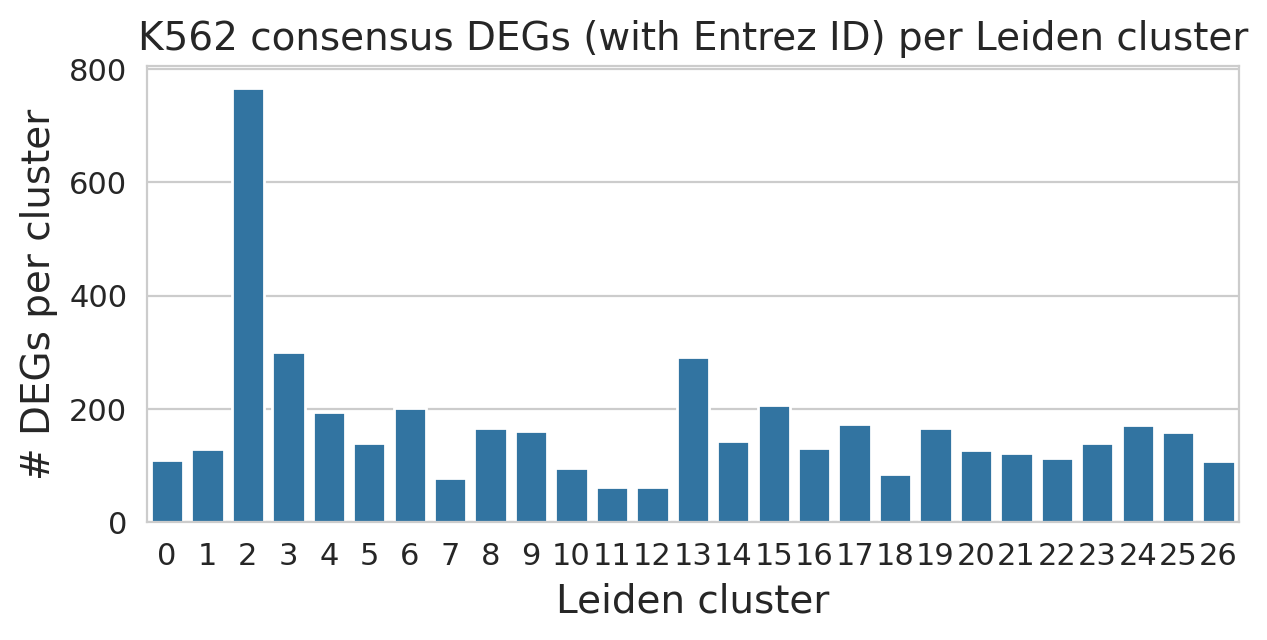

In [24]:
_ = plot_n_DEGs_per_cluster(cluster_entrez_deg_dict,
                            title="K562 consensus DEGs (with Entrez ID) per Leiden cluster",
                            figsize=(7,3), xlabel="Leiden cluster")

# Consensus LFC table for pathview/SBGNview

In [21]:
def build_consensus_lfc_dfs(
        DGE_results_dfs: list[pd.DataFrame],
        cluster_df: pd.DataFrame,
        p_threshold: float,
        p_threshold_type: str = "pvalue",
        lfc_col: str = "log2FoldChange",
        lfc_threshold: float = 0,
        remove_self_DEGs: bool=True
        ) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Build 2 DataFrames for pathway visualization, one 
    with consensus LFC values for each TF KD and one with 
    consensus LFC values for each cluster.

    If a gene is a DEG of a KD in at least 2 out of 3 DGE runs, it
    is a consensus DEG. For each KD, compute consensus LFC of each
    consensus DEG (take mean LFC of gene across any run where gene
    passes significance and LFC thresholds). Then for each cluster,
    for each gene, take mean of consensus LFCs across all cluster KDs.
    """
    # Check that DGE results DFs have same rows and cols
    DGE_results_dfs = validate_3_DGE_results_dfs(DGE_results_dfs)
    
    # Build dict of KD: {consensus DEGs}
    DEGs_dict = build_3_run_DEGs_dict(DGE_results_dfs,
                                      p_threshold=p_threshold,
                                      p_threshold_type=p_threshold_type,
                                      target_type="gene_target",
                                      lfc_threshold=lfc_threshold,
                                      lfc_col=lfc_col,
                                      validate=False,
                                      remove_self_DEGs=remove_self_DEGs)
    
    # Get per-run LFC values
    kds = sorted(list(DEGs_dict.keys()))
    masked_run_lfc_dfs = list()
    for DGE_df in DGE_results_dfs:
        masked_lfc_cols = dict()
        for kd in kds:
            kd_p_col = DGE_df[f"{kd}_{p_threshold_type}"]
            kd_lfc_col = DGE_df[f"{kd}_{lfc_col}"].copy()
            # Get LFCs for genes that pass significance/LFC thresholds
            passes_run = (
                (kd_p_col < p_threshold) & (kd_lfc_col.abs() > lfc_threshold)
            ).fillna(False)
            # Set LFCs of genes that are not consensus DEGs to NaN
            in_consensus = kd_lfc_col.index.isin(DEGs_dict[kd])
            keep = passes_run.values & in_consensus
            kd_lfc_col[~keep] = np.nan
            # Add LFC col to dict
            masked_lfc_cols[kd] = kd_lfc_col
        # Add LFC cols for DGE run to list
        masked_run_lfc_df = pd.DataFrame(masked_lfc_cols, index=DGE_df.index)
        masked_run_lfc_dfs.append(masked_run_lfc_df)
    
    # Take mean LFCs across runs (skip NaNs)
    kd_consensus_lfc_df = pd.concat(masked_run_lfc_dfs).groupby(level=0).mean()

    # Build cluster LFC DF
    cluster_kd_dict = {
        int(cl): list(cluster_df[cl][cluster_df[cl].notna()])
        for cl in cluster_df.columns
    }
    cluster_lfc_cols = {}
    for cluster_num, cluster_kds in cluster_kd_dict.items():
        # Take mean LFC of each gene across cluster TF KDs
        cluster_lfc_cols[cluster_num] = \
            kd_consensus_lfc_df[cluster_kds].mean(axis=1).fillna(0)
    cluster_consensus_lfc_df = pd.DataFrame(cluster_lfc_cols, 
                                            index=kd_consensus_lfc_df.index)

    # Set NaN values to 0 in KD LFC DF
    kd_consensus_lfc_df = kd_consensus_lfc_df.fillna(0)
    
    return kd_consensus_lfc_df, cluster_consensus_lfc_df

In [22]:
filepath1 = "/home/ranwyl/results_tf_project/K562_DE_results_KD_shrunk_seed42_5-14-26_entrez.pkl"
de_results_entrez_k562_1 = pd.read_pickle(filepath1)
filepath2 = "/home/ranwyl/results_tf_project/K562_DE_results_KD_shrunk_seed12_5-14-26_entrez.pkl"
de_results_entrez_k562_2 = pd.read_pickle(filepath2)
filepath3 = "/home/ranwyl/results_tf_project/K562_DE_results_KD_shrunk_seed123_5-14-26_entrez.pkl"
de_results_entrez_k562_3 = pd.read_pickle(filepath3)
de_results_entrez_k562 = [de_results_entrez_k562_1, de_results_entrez_k562_2,
                          de_results_entrez_k562_3]

In [23]:
k562_kd_consensus_lfc_df, k562_cluster_consensus_lfc_df = \
    build_consensus_lfc_dfs(de_results_entrez_k562,
                            cluster_df=leiden_clusters_k562,
                            p_threshold=0.005, p_threshold_type="pvalue",
                            remove_self_DEGs=True)

In [24]:
k562_kd_consensus_lfc_df.head()

,ADNP,ADNP2,AEBP1,AEBP2,AHCTF1,AHRR,AIRE,AKAP8,AKAP8L,AKNA,...,ZNF92,ZNF98,ZSCAN12,ZSCAN18,ZSCAN20,ZSCAN21,ZSCAN22,ZSCAN30,ZSCAN5A,ZSCAN9
gene_name,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
100,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10005,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10006,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [25]:
k562_kd_consensus_lfc_df[["DNMT1"]].head()

,DNMT1
gene_name,
1,0.000000
100,-0.697518
10001,0.000000
10005,0.000000
10006,0.000000


In [26]:
filepath = "/home/ranwyl/output_files_tf_project/K562_KD_lfcs_pathview_6-4-26.csv"
k562_kd_consensus_lfc_df.to_csv(filepath)

In [27]:
k562_cluster_consensus_lfc_df.head()

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
gene_name,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
100,0.0,0.0,0.0,0.0,-0.697518,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10001,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10005,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10006,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [28]:
filepath = "/home/ranwyl/output_files_tf_project/K562_leiden_cluster_lfcs_pathview_6-4-26.csv"
k562_cluster_consensus_lfc_df.to_csv(filepath)

# TF-target dict

In [ ]:
def build_tf_target_dict_signed(source_list: list[str] = ["CollecTRI", "DoRothEA", 
                                                          "TF_Perturbations_Followed_by_Expression",
                                                          "TF-LOF_Expression_from_GEO"], 
                                tfs_to_rename_dict: dict[str, list] | None = None, 
                                dorothea_levels=["A", "B", "C"]) -> dict[str, dict[str, set[str]]]:
    """
    Build dict {TF: {"UP": set of upreg genes, "DOWN": set of downreg genes}}
    using decoupler and gseapy.
    """
    all_dicts = list()

    if "CollecTRI" in source_list:
        collectri_df = dc.op.collectri(organism='human')
        collectri_dict = dict()
        for tf, gene, weight in collectri_df.iloc[:,:3].itertuples(index=False, name=None):
            if tf not in collectri_dict:
                collectri_dict[tf] = {"UP":set(), "DOWN":set()}
            if weight > 0: # TF is activator --> gene is downregulated
                collectri_dict[tf]["DOWN"].add(gene)
            else: # TF is repressor --> gene is upregulated
                collectri_dict[tf]["UP"].add(gene)
        all_dicts.append(collectri_dict)
    
    if "DoRothEA" in source_list:
        dorothea_df = dc.op.dorothea(organism='human', levels=dorothea_levels)
        dorothea_dict = dict()
        for tf, gene, weight in dorothea_df.iloc[:,:3].itertuples(index=False, name=None):
            if tf not in dorothea_dict:
                dorothea_dict[tf] = {"UP":set(), "DOWN":set()}
            if weight > 0:
                dorothea_dict[tf]["DOWN"].add(gene)
            else:
                dorothea_dict[tf]["UP"].add(gene)
        all_dicts.append(dorothea_dict)

    # Perturbation and LOF Enrichr libraries
    ko_lof_lib_list = list()
    if "TF_Perturbations_Followed_by_Expression" in source_list:
        pert_lib = gp.get_library(name="TF_Perturbations_Followed_by_Expression")
        ko_lof_lib_list.append(pert_lib)
    if "TF-LOF_Expression_from_GEO" in source_list:
        lof_lib = gp.get_library("TF-LOF_Expression_from_GEO")
        ko_lof_lib_list.append(lof_lib)
    if ko_lof_lib_list:
        ko_lof_dict = dict()
        for lib in ko_lof_lib_list:
            for tf_label, genes in lib.items():
                tf_label = tf_label.upper()
                if "HUMAN" in tf_label:
                    tf_label = tf_label.split(" ")
                    tf, reg = tf_label[0], tf_label[-1]
                    if tf not in ko_lof_dict:
                        ko_lof_dict[tf] = {"UP":set(), "DOWN":set()}
                    if reg == "UP":
                        ko_lof_dict[tf]["UP"].update(set(genes))
                    elif reg == "DOWN":
                        ko_lof_dict[tf]["DOWN"].update(set(genes))
        if tfs_to_rename_dict:
            for old_name, new_name in tfs_to_rename_dict.items():
                if new_name == "":
                    ko_lof_dict.pop(old_name)
                else:
                    ko_lof_dict[new_name] = ko_lof_dict.pop(old_name)
        all_dicts.append(ko_lof_dict)

    # Combine
    if len(all_dicts) == 1:
        return all_dicts[0]
    all_tfs = {tf for target_dict in all_dicts for tf in target_dict.keys()}
    all_tf_targets_dict = {tf: {"UP": set(), "DOWN": set()} for tf in all_tfs}
    for tf in all_tfs:
        genes_up = {g for target_dict in all_dicts if tf in target_dict for g in target_dict[tf]["UP"]}
        genes_down = {g for target_dict in all_dicts if tf in target_dict for g in target_dict[tf]["DOWN"]}
        all_tf_targets_dict[tf]["UP"].update(genes_up)
        all_tf_targets_dict[tf]["DOWN"].update(genes_down)
    return all_tf_targets_dict

In [ ]:
import pickle

In [ ]:
tfs_rename_dict = {"NCOA":"", "RENT1":"UPF1", "HIF2A":"EPAS1"} # old name : new name
tf_target_interactions_dict = build_tf_target_dict_signed(
    ["CollecTRI", "DoRothEA", "TF_Perturbations_Followed_by_Expression", "TF-LOF_Expression_from_GEO"], 
    tfs_to_rename_dict=tfs_rename_dict)

2026-03-05 14:31:34 | [INFO] Downloading and generating Enrichr library gene sets...
2026-03-05 14:31:54 | [INFO] Downloading and generating Enrichr library gene sets...
2026-03-05 14:32:16 | [INFO] 0017 gene_sets have been filtered out when max_size=2000 and min_size=0


Save as pickle

In [ ]:
tf_target_dict_filepath = "/home/ranwyl/reference_tf_project/tf_target_signed_interactions.pkl"
with open(tf_target_dict_filepath, 'wb') as f: # binary write mode
    pickle.dump(tf_target_interactions_dict, f)

In [ ]:
# TF target dict

import pickle

tf_target_dict_filepath = "/home/ranwyl/reference_tf_project/tf_target_signed_interactions.pkl"
with open(tf_target_dict_filepath, 'rb') as f: # binary read mode
    tf_target_interactions_dict = pickle.load(f)

# Cluster-level GSEA

In [10]:
# Handle warnings
@contextmanager
def handle_warnings(suppress):
    if suppress:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            yield
    else:
        yield

def prerank_gsea_all_kds(
        cluster_df: pd.DataFrame,
        DGE_results_dfs: list[pd.DataFrame],
        gene_set_name: str,
        cell_line: str,
        add_jitter: bool=True,
        wald_label: str="stat",
        min_term_size: int=15, 
        max_term_size: int=200,
        permutation_num: int=1000,
        n_cpus_per_job: int=4,
        n_jobs: int=8,
        joblib_timeout: float | None = None,
        random_seed: int=42,
        verbose: bool=False,
        kd_col: str="KD",
        cluster_col: str="Cluster",
        gene_set_col: str="Gene set",
        cell_line_col: str="Cell line",
        suppress_warnings: bool=False
        ) -> pd.DataFrame:
    """
    Run pre-ranked GSEA, using the given Enrichr library, on each 
    individual KD in a dataset. For each KD, compute mean Wald test
    statistic of each gene across 3 DGE analysis runs and rank genes by
    mean Wald. min_size controls minimum number of genes in the intersection
    of the dataset and each gene set term. max_size controls maximum number of
    genes in each gene set term.
    """
    # Get KDs
    kds = cluster_df.values.flatten().tolist()
    kds = [kd for kd in kds if isinstance(kd, str)] # Remove NaN column padding
    kd_to_cluster = {kd: int(col) for col in cluster_df.columns 
                     for kd in cluster_df[col].dropna()}
    # Check for duplicates
    assert len(kd_to_cluster) == len(kds), (
        f"{len(kds) - len(kd_to_cluster)} KD(s) appear in multiple clusters")

    # Get Enrichr library
    gene_set = gp.get_library(gene_set_name, organism="Human",
                              min_size=min_term_size, max_size=max_term_size)
    
    # Check that 3 DGE analysis results DFs have same rows and cols
    DGE_results_dfs = validate_3_DGE_results_dfs(DGE_results_dfs)
    # Subset DGE results to Wald columns only
    wald_cols = [col for col in DGE_results_dfs[0].columns if col.endswith(f"_{wald_label}")]
    DGE_results_dfs = [df[wald_cols] for df in DGE_results_dfs]
    
    # Helper function to run GSEA on single KD
    def process_kd(kd):
        # Compute mean Wald per gene
        wald_col = f"{kd}_{wald_label}"
        wald_df_1 = pd.DataFrame(DGE_results_dfs[0][wald_col].values,
                                 index=DGE_results_dfs[0].index, 
                                 columns=[wald_label])
        wald_df_2 = pd.DataFrame(DGE_results_dfs[1][wald_col].values,
                                 index=DGE_results_dfs[1].index, 
                                 columns=[wald_label])
        wald_df_3 = pd.DataFrame(DGE_results_dfs[2][wald_col].values,
                                 index=DGE_results_dfs[2].index, 
                                 columns=[wald_label])
        wald_df = (wald_df_1 + wald_df_2 + wald_df_3) / 3
        # Drop NaN genes and gene that was KD
        if kd in wald_df.index:
            wald_df.loc[kd] = np.nan
        wald_df.dropna(axis="index", inplace=True)
        # Sort and format Wald DF
        wald_df.sort_values(by=wald_label, ascending=False, inplace=True)
        wald_df.index.name = "gene"
        # Add negligible jitter to break ties
        if add_jitter:
            jitter = 1e-9 * np.arange(len(wald_df))
            wald_df[wald_label] = wald_df[wald_label].values - jitter

        # Run pre-ranked GSEA
        kd_gsea_result = \
            gp.prerank(rnk=wald_df,
                        gene_sets=gene_set,
                        threads=n_cpus_per_job,
                        min_size=min_term_size,
                        max_size=max_term_size,
                        permutation_num=permutation_num,
                        outdir=None,
                        seed=random_seed,
                        verbose=verbose,
                        )
        return kd_gsea_result
    
    # Run pre-ranked GSEA on all KDs
    with handle_warnings(suppress_warnings):
        with tqdm_joblib(desc="Running pre-ranked GSEA", 
                            total=len(kds)):
            kd_gsea_results = Parallel(n_jobs=n_jobs, timeout=joblib_timeout)(
                delayed(process_kd)(kd) for kd in kds)
    kd_gsea_results_dict = dict(zip(kds, kd_gsea_results))

    # Build results DF
    gsea_results_list = list()
    for kd in kd_gsea_results_dict: # Build results DF for KD
        kd_res_df = kd_gsea_results_dict[kd].res2d.copy()
        kd_res_df.insert(0, kd_col, [kd]*kd_res_df.shape[0]) # KD column
        kd_res_df.drop(columns=["Name"], inplace=True)
        gsea_results_list.append(kd_res_df)
    gsea_results_df = pd.concat(gsea_results_list)
    # Add gene set, cluster, and cell line info
    gsea_results_df.insert(1, gene_set_col, [gene_set_name]*len(gsea_results_df))
    gsea_results_df.insert(0, cluster_col, gsea_results_df[kd_col].map(kd_to_cluster))
    gsea_results_df.insert(0, cell_line_col, [cell_line]*len(gsea_results_df))

    # Check that all KDs are in DF
    gsea_kds = set(gsea_results_df[kd_col])
    missing_kds = set(kds) - gsea_kds
    if missing_kds:
        print(f"Warning: {len(missing_kds)} KDs missing from GSEA results ({', '.join(missing_kds)})")
    
    return gsea_results_df

In [11]:
def build_enriched_gsea_terms_df(
        prerank_results_df: pd.DataFrame,
        DGE_results_dfs: list[pd.DataFrame],
        fdr_threshold: float=0.05,
        fdr_col: str="FDR q-val",
        min_absolute_nes: None | float = None, 
        nes_col: str="NES",
        DGE_p_threshold: float = 0.05,
        DGE_p_threshold_type: str="pvalue",
        wald_label: str = "stat",
        wald_abs_threshold: int=1,
        leading_genes_col: str="Lead_genes",
        kd_DEG_dict: dict[str, set[str]] | None = None,
        kd_wald_dict: dict[str, set[str]] | None = None,
        cluster_col: str="Cluster",
        kd_col: str="KD",
    ) -> pd.DataFrame:
    """
    Subset the GSEA results DF to only enriched terms
    and add info on leading genes that are DEGs and
    that have |Wald| > 1 in at least 2 DGE analysis runs.
    """
    # Check that 3 DGE analysis results DFs have same rows and cols
    DGE_results_dfs = validate_3_DGE_results_dfs(DGE_results_dfs)

    # Subset to enriched terms (by FDR and NES)
    prerank_results_df = \
        prerank_results_df[prerank_results_df[fdr_col] < fdr_threshold]
    if min_absolute_nes:
        prerank_results_df = \
            prerank_results_df[prerank_results_df[nes_col] >= min_absolute_nes]
    enriched_results_df = prerank_results_df.copy()
    
    # Add info on leading genes that pass DE significance threshold
    #   and have |Wald| > threshold in at least 2 DGE runs
    # Build dict {KD: {DEGs}}
    kds = set(prerank_results_df[kd_col].values)
    if not kd_DEG_dict:
        kd_DEG_dict = build_3_run_DEGs_dict(DGE_results_dfs, 
                                            p_threshold=DGE_p_threshold,
                                            p_threshold_type=DGE_p_threshold_type,
                                            validate=False)
    kd_DEG_dict = {k:v for k,v in kd_DEG_dict.items() if k in kds}
    # Build dict {KD: {genes with |Wald| > threshold}}
    if not kd_wald_dict:
        kd_wald_dict = build_3_run_wald_dict(DGE_results_dfs, 
                                            wald_col=wald_label,
                                            wald_abs_threshold=wald_abs_threshold,
                                            validate=False)
    kd_wald_dict = {k:v for k,v in kd_wald_dict.items() if k in kds}
    
    # Get leading gene DE + Wald info
    kds_arr = enriched_results_df[kd_col].to_numpy()
    lead_genes_arr = enriched_results_df[leading_genes_col].to_numpy()
    n_de_leading, de_leading_str, n_wald_leading, wald_leading_str = [], [], [], []
    for kd, lead_genes in zip(kds_arr, lead_genes_arr):
        leading_genes = set(s for s in lead_genes.split(";") if s)
        de_leading = leading_genes & kd_DEG_dict.get(kd, set())
        wald_leading = leading_genes & kd_wald_dict.get(kd, set())
        n_de_leading.append(len(de_leading))
        de_leading_str.append(";".join(sorted(de_leading)))
        n_wald_leading.append(len(wald_leading))
        wald_leading_str.append(";".join(sorted(wald_leading)))
    
    # Add leading gene DE + Wald info to DF
    enriched_results_df.insert(10, "# DE lead genes", n_de_leading)
    enriched_results_df.insert(11, f"# lead genes w/ |Wald| > {wald_abs_threshold}", 
                               n_wald_leading)
    enriched_results_df["DE_lead_genes"] = de_leading_str
    enriched_results_df["Wald_lead_genes"] = wald_leading_str
    
    # Sort DF
    enriched_results_df.sort_values(by=[cluster_col, kd_col, nes_col],
                                    ascending=[True, True, False],
                                    inplace=True, ignore_index=True)
    
    return enriched_results_df

def build_cluster_shared_gsea_terms_df(
        enriched_results_df: pd.DataFrame,
        gene_set_name: str,
        cell_line: str,
        min_cluster_kds: int=3,
        min_term_size: int=15, 
        max_term_size: int=200,
        kd_col: str="KD",
        cluster_col: str="Cluster", 
        nes_col: str="NES",
        gene_set_col: str="Gene set",
        cell_line_col: str="Cell line",
        leading_genes_col: str="Lead_genes",
        DE_leading_genes_col: str="DE_lead_genes",
        wald_leading_genes_col: str="Wald_lead_genes",
        wald_abs_threshold: float = 1
        ) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Given a pre-ranked GSEA results DF with enriched terms and
    info on genes that pass DE and |Wald| thresholds, find terms 
    shared between multiple cluster KDs.
    """
    cluster_results_dfs, summary_entries = list(), list()
    # Get Enrichr library
    enrichr_library = gp.get_library(gene_set_name, organism="Human",
                                 min_size=min_term_size, max_size=max_term_size)
    # Loop through clusters
    clusters = sorted(enriched_results_df[cluster_col].unique().tolist(), key=int)
    for cl in clusters:
        # Get cluster DF
        cl_df = enriched_results_df[enriched_results_df[cluster_col] == cl]
        if cl_df.empty:
            continue
        # Group cluster DF by term for fast lookup
        term_groups = dict(list(cl_df.groupby("Term", sort=False)))
        # Subset to shared terms
        term_counts = cl_df["Term"].value_counts()
        cl_shared_terms = set(term_counts[term_counts >= min_cluster_kds].index)
        cl_shared_direction_terms = set()
        for term in cl_shared_terms:
            # Get only shared terms where all TF KDs have same NES sign
            cl_term_df = term_groups[term]
            nes_values = cl_term_df[nes_col].to_numpy()
            if not (np.all(nes_values > 0) or np.all(nes_values < 0)):
                continue
            cl_shared_direction_terms.add(term)
            # Build summary entry and add to list
            term_kds = sorted(cl_term_df[kd_col].unique().tolist())
            term_lead_genes = \
                {g for genes in cl_term_df[leading_genes_col].values 
                 for g in genes.split(";") if g}
            term_DE_lead_genes = \
                {g for genes in cl_term_df[DE_leading_genes_col].values 
                 for g in genes.split(";") if g}
            term_wald_lead_genes = \
                {g for genes in cl_term_df[wald_leading_genes_col].values 
                 for g in genes.split(";") if g}
            wald_lead_genes_col = f"Total leading genes w/ |Wald| > {wald_abs_threshold}"
            summary_entries.append(
                {cluster_col: cl, 
                 "Term": term, 
                 f"# {kd_col}s": len(term_kds),
                 f"{kd_col}s": ", ".join(term_kds),
                 "Mean NES": round(cl_term_df[nes_col].mean(), 2),
                 "Term size": len(enrichr_library[term]),
                 "Total leading genes": len(term_lead_genes),
                 "Total DE leading genes": len(term_DE_lead_genes),
                 wald_lead_genes_col: len(term_wald_lead_genes)}
                 )
        # Add cluster shared terms DF to list
        cl_df = cl_df[cl_df["Term"].isin(cl_shared_direction_terms)]
        cl_df.sort_values(by=["Term", kd_col], inplace=True)
        cluster_results_dfs.append(cl_df)
    
    # If no enriched terms
    if len(cluster_results_dfs) == 0:
        return pd.DataFrame(), pd.DataFrame()
    
    # Build shared terms DF
    if len(cluster_results_dfs) > 1:
        shared_terms_df = pd.concat(cluster_results_dfs)
        shared_terms_df.reset_index(drop=True, inplace=True)
    else:
        shared_terms_df = cluster_results_dfs[0]
    # Build summary DF
    summary_df = pd.DataFrame(summary_entries)
    summary_df.insert(0, cell_line_col, [cell_line]*len(summary_df))
    summary_df.insert(1, gene_set_col, [gene_set_name]*len(summary_df))
    summary_df.sort_values(by=[cluster_col, "Mean NES", f"# {kd_col}s"], 
                           ascending=[True, False, False],
                           inplace=True, ignore_index=True)

    return shared_terms_df, summary_df

def combine_gsea_dfs(gsea_dfs: list[pd.DataFrame],
                     cluster_col: str="Cluster",
                     kd_col: str="KD",
                     nes_col: str="NES") -> pd.DataFrame:
    """
    Concatenate and sort multiple GSEA results DFs where each row is a term.
    """
    gsea_df = pd.concat(gsea_dfs)
    gsea_df.sort_values(by=[cluster_col, kd_col, nes_col],
                        ascending=[True, True, False],
                        inplace=True, ignore_index=True)
    return gsea_df

def summarize_gsea_df(gsea_df: pd.DataFrame,
                    cluster_df: pd.DataFrame,
                    gene_set_col: str="Gene set",
                    kd_col: str="KD",
                    fdr_threshold: float=0.05,
                    fdr_col: str="FDR q-val",
                    cluster_col: str="Cluster"
                    ) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Given a GSEA results DF where each row is a term, summarize the
    number of enriched terms and enriched KDs per gene set and per cluster.
    """
    gsea_df = gsea_df[gsea_df[fdr_col] < fdr_threshold]

    # Gene set info
    kds = cluster_df.values.flatten().tolist()
    kds = [kd for kd in kds if isinstance(kd, str)]
    total_n_kds = len(kds)
    gene_sets = sorted(gsea_df[gene_set_col].unique().tolist())
    gene_set_n_enriched_terms = list()
    gene_set_n_enriched_kds = list()
    for gene_set in gene_sets:
        df_subset = gsea_df[gsea_df[gene_set_col] == gene_set]
        gene_set_n_enriched_terms.append(len(df_subset))
        gene_set_n_enriched_kds.append(
            f"{df_subset[kd_col].nunique()}/{total_n_kds}")
    gene_set_summary_df = pd.DataFrame({
        "# enriched terms": gene_set_n_enriched_terms,
        f"# {kd_col}s with enriched term(s)": gene_set_n_enriched_kds
        }, index=gene_sets)
    gene_set_summary_df.index.name = gene_set_col
    gene_set_summary_df.sort_values(by="# enriched terms", 
                                    ascending=False, inplace=True)
    
    # Cluster info
    clusters_n_kds = {int(cl): len(cluster_df[cl][cluster_df[cl].notna()])
                      for cl in cluster_df.columns}
    clusters_n_kds = {cl: clusters_n_kds[cl] for cl in sorted(clusters_n_kds.keys())}
    cluster_n_enriched_terms = list()
    cluster_n_enriched_kds = list()
    for cl in clusters_n_kds.keys():
        cl_n_enriched_terms = 0
        cl_n_enriched_kds = 0
        if cl in gsea_df[cluster_col].values:
            df_subset = gsea_df[gsea_df[cluster_col] == cl]
            cl_n_enriched_terms = len(df_subset)
            cl_n_enriched_kds = df_subset[kd_col].nunique()
        cluster_n_enriched_terms.append(cl_n_enriched_terms)
        cluster_n_enriched_kds.append(
            f"{cl_n_enriched_kds}/{clusters_n_kds[cl]}")
    cluster_summary_df = pd.DataFrame({
        "# enriched terms": cluster_n_enriched_terms,
        f"# cluster {kd_col}s w/ enriched terms": cluster_n_enriched_kds
        }, index=list(clusters_n_kds.keys()))
    cluster_summary_df.sort_values(by="# enriched terms", ascending=False,
                                   inplace=True)
    cluster_summary_df.index.name = cluster_col
    return gene_set_summary_df, cluster_summary_df

def combine_gsea_shared_summary_dfs(gsea_shared_summary_dfs: list[pd.DataFrame],
                                    cluster_col: str="Cluster",
                                    kd_col: str="KD") -> pd.DataFrame:
    """
    Concatenate and sort multiple GSEA results DFs where each row corresponds
    to a term shared by multiple KDs in a cluster.
    """
    gsea_shared_df = pd.concat(gsea_shared_summary_dfs)
    gsea_shared_df.sort_values(by=[cluster_col, "Mean NES", f"# {kd_col}s"], 
                                ascending=[True, False, False],
                                inplace=True, ignore_index=True)
    return gsea_shared_df

def summarize_gsea_shared_df(gsea_shared_df: pd.DataFrame,
                            cluster_df: pd.DataFrame,
                            gene_set_col: str="Gene set",
                            kd_col: str="KD",
                            cluster_col: str="Cluster"
                            ) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Given a GSEA results DF where each row corresponds to a term shared 
    by multiple KDs in a cluster, summarize the number of shared enriched terms 
    and KDs with shared enriched terms per gene set and per cluster.
    """
    # Gene set info
    kds = cluster_df.values.flatten().tolist()
    kds = [kd for kd in kds if isinstance(kd, str)]
    total_n_kds = len(kds)
    gene_sets = sorted(gsea_shared_df[gene_set_col].unique().tolist())
    gene_set_n_shared_terms = list()
    gene_set_n_shared_kds = list()
    for gene_set in gene_sets:
        df_subset = gsea_shared_df[gsea_shared_df[gene_set_col] == gene_set]
        gene_set_n_shared_terms.append(len(df_subset))
        gs_kd_vals = list(df_subset[f"{kd_col}s"].values)
        gs_n_shared_kds = len({kd for val in gs_kd_vals 
                               for kd in val.split(", ")})
        gene_set_n_shared_kds.append(f"{gs_n_shared_kds}/{total_n_kds}")
    gene_set_summary_df = pd.DataFrame({
        "# shared terms": gene_set_n_shared_terms,
        f"# {kd_col}s w/ shared terms": gene_set_n_shared_kds
        }, index=gene_sets)
    gene_set_summary_df.index.name = gene_set_col
    gene_set_summary_df.sort_values(by="# shared terms", 
                                    ascending=False, inplace=True)
    
    # Cluster info
    clusters_n_kds = {int(cl): len(cluster_df[cl][cluster_df[cl].notna()])
                      for cl in cluster_df.columns}
    clusters_n_kds = {cl: clusters_n_kds[cl] for cl in sorted(clusters_n_kds.keys())}
    cluster_n_shared_terms = list()
    cluster_n_shared_kds = list()
    for cl in clusters_n_kds.keys():
        cl_n_shared_terms = 0
        cl_n_shared_kds = 0
        if cl in gsea_shared_df[cluster_col].values:
            df_subset = gsea_shared_df[gsea_shared_df[cluster_col] == cl]
            cl_n_shared_terms = len(df_subset)
            cl_kd_vals = list(df_subset[f"{kd_col}s"].values)
            cl_n_shared_kds = len({kd for val in cl_kd_vals 
                                   for kd in val.split(", ")})
        cluster_n_shared_terms.append(cl_n_shared_terms)
        cluster_n_shared_kds.append(
            f"{cl_n_shared_kds}/{clusters_n_kds[cl]}")
    cluster_summary_df = pd.DataFrame({
        "# shared enriched terms": cluster_n_shared_terms,
        f"# cluster {kd_col}s w/ shared enriched terms": cluster_n_shared_kds
        }, index=list(clusters_n_kds.keys()))
    cluster_summary_df.sort_values(by="# shared enriched terms", ascending=False,
                                   inplace=True)
    cluster_summary_df.index.name = cluster_col
    return gene_set_summary_df, cluster_summary_df

## Check for ties in ranking DataFrames

Check for ties in mean Wald DataFrames for pre-ranked GSEA to see if it is appropriate to add jitter that mitigates tie warnings from gseapy. Flag any TF KD with ties in the top 5% or bottom 5% ranked genes.

In [13]:
def check_wald_ties(cluster_df: pd.DataFrame,
                    DGE_results_dfs: list[pd.DataFrame], 
                    wald_label: str="stat",
                    top_frac: float = 0.05):
    """
    For each KD, check for ties in the mean Wald DataFrame for pre-ranked GSEA.
    """
    # Get KDs
    kds = cluster_df.values.flatten().tolist()
    kds = [kd for kd in kds if isinstance(kd, str)] # Remove NaN column padding
    # Check that 3 DGE analysis results DFs have same rows and cols
    DGE_results_dfs = validate_3_DGE_results_dfs(DGE_results_dfs)
    # Subset DGE results to Wald columns only
    wald_cols = [col for col in DGE_results_dfs[0].columns if col.endswith(f"_{wald_label}")]
    DGE_results_dfs = [df[wald_cols] for df in DGE_results_dfs]

    # Get tie info for each KD
    tie_records = list()
    for kd in kds:
        # Compute mean Wald per gene
        wald_col = f"{kd}_{wald_label}"
        wald_df_1 = pd.DataFrame(DGE_results_dfs[0][wald_col].values,
                                 index=DGE_results_dfs[0].index, 
                                 columns=[wald_label])
        wald_df_2 = pd.DataFrame(DGE_results_dfs[1][wald_col].values,
                                 index=DGE_results_dfs[1].index, 
                                 columns=[wald_label])
        wald_df_3 = pd.DataFrame(DGE_results_dfs[2][wald_col].values,
                                 index=DGE_results_dfs[2].index, 
                                 columns=[wald_label])
        wald_df = (wald_df_1 + wald_df_2 + wald_df_3) / 3
        # Drop NaN genes and gene that was KD
        if kd in wald_df.index:
            wald_df.loc[kd] = np.nan
        wald_df.dropna(axis="index", inplace=True)
        # Sort and format Wald DF
        wald_df.sort_values(by=wald_label, ascending=False, inplace=True)
        wald_df.index.name = "gene"

        # Report tie information
        vals = wald_df[wald_label].values
        n = len(vals)
        if n == 0:
            tie_records.append({
                "KD": kd, "n_genes": 0, "n_tied": 0, "frac_tied": np.nan,
                "max_tie_group": 0, "n_tied_in_top_extremes": 0,
                "n_exactly_zero": 0,
            })
            continue
    
        unique_vals, counts = np.unique(vals, return_counts=True)
        n_tied = int(n - len(unique_vals))          # genes sharing a value
        max_tie_group = int(counts.max())           # largest identical block
        n_exactly_zero = int(np.sum(vals == 0))     # exact zeros specifically

        # Ties among the extremes
        top_k = max(1, int(top_frac * n))
        extreme_vals = np.concatenate((vals[:top_k], vals[-1*top_k:]))
        n_tied_in_top_extremes = int(top_k - len(np.unique(extreme_vals)))

        tie_records.append({
            "KD": kd,
            "n_genes": n,
            "n_tied": n_tied,
            "frac_tied": n_tied / n,
            "max_tie_group": max_tie_group,
            "n_tied_in_top_extremes": n_tied_in_top_extremes,
            "n_exactly_zero": n_exactly_zero,
        })

    tie_df = pd.DataFrame(tie_records).set_index("KD")

    # Summary
    n_kds = len(tie_df)
    valid = tie_df[tie_df["n_genes"] > 0]
    print(f"Checked {n_kds} KDs ({(tie_df['n_genes'] == 0).sum()} empty after filtering)")
    print(f"frac_tied:    max {valid['frac_tied'].max():.4%}  "
          f"median {valid['frac_tied'].median():.4%}")
    print(f"max_tie_group: max {int(valid['max_tie_group'].max())}  "
          f"median {int(valid['max_tie_group'].median())}")
    print(f"KDs with ties among top {top_frac:.0%} or bottom {top_frac:.0%} values: "
          f"{(valid['n_tied_in_top_extremes'] > 0).sum()}")
    print(f"KDs with any exact zeros: {(valid['n_exactly_zero'] > 0).sum()}  "
          f"(max {int(valid['n_exactly_zero'].max())})")

    # Flag KDs worth inspecting before jittering
    flagged = valid[
        (valid["n_tied_in_top_extremes"] > 0) |
        (valid["n_exactly_zero"] > 0.01 * valid["n_genes"]) |
        (valid["frac_tied"] > 0.10)
        ].copy()
    if len(flagged):
        flagged = flagged.sort_values(
            ["n_tied_in_top_extremes", "frac_tied"],
            ascending=False)
        print(f"\n{len(flagged)} KD(s) flagged for inspection "
              f"(tied extremes, >1% exact zeros, or frac_tied>10%):")
        print(flagged.to_string())
    else:
        print("\nNo KDs flagged — ties are sparse and concentrated away from "
              "extremes; jitter is safe.")

    return tie_df

In [14]:
kolf_tie_df = check_wald_ties(leiden_clusters_k562, de_results_k562)

Checked 429 KDs (0 empty after filtering)
frac_tied:    max 0.0000%  median 0.0000%
max_tie_group: max 1  median 1
KDs with ties among top 5% or bottom 5% values: 0
KDs with any exact zeros: 0  (max 0)

No KDs flagged — ties are sparse and concentrated away from extremes; jitter is safe.


Do not need to add jitter since there are no ties.

## Hallmark

In [25]:
k562_hallmark_results = prerank_gsea_all_kds(
    cluster_df=leiden_clusters_k562,
    DGE_results_dfs=de_results_k562,
    gene_set_name="MSigDB_Hallmark_2020",
    cell_line="K562",
    min_term_size=15,
    max_term_size=200,
    permutation_num=10000,
    n_jobs=16,
    n_cpus_per_job=4,
    kd_col="TF KD",
    add_jitter=False,
    suppress_warnings=True)

2026-06-22 14:36:53 | [INFO] Downloading and generating Enrichr library gene sets...
2026-06-22 14:36:53 | [INFO] Library is already downloaded in: /home/ranwyl/.cache/gseapy/Enrichr.MSigDB_Hallmark_2020.gmt, use local file


Running pre-ranked GSEA:   0%|          | 0/429 [00:00<?, ?it/s]

In [26]:
k562_hallmark_results.head()

,Cell line,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,K562,0,ALX3,MSigDB_Hallmark_2020,Myc Targets V1,-0.386462,-1.92881,0.0,0.00239,0.0037,98/195,31.46%,CDK2;HSPE1;CDK4;C1QBP;NPM1;RPS6;FAM120A;HSPD1;...
1,K562,0,ALX3,MSigDB_Hallmark_2020,Myc Targets V2,-0.447438,-1.800669,0.00153,0.005684,0.0175,20/56,16.76%,SLC19A1;HSPE1;TMEM97;CDK4;NPM1;SORD;IPO4;HSPD1...
2,K562,0,ALX3,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.468341,1.7594,0.003299,0.03744,0.0286,17/45,15.80%,JUN;TGFBR3;SAT1;LGALS1;WIPF1;TPM4;VEGFA;GADD45...
3,K562,0,ALX3,MSigDB_Hallmark_2020,Hypoxia,0.407727,1.742681,0.000358,0.023673,0.036,30/88,19.45%,JUN;DDIT3;ATF3;PNRC1;TES;ANXA2;BNIP3L;MXI1;VEG...
4,K562,0,ALX3,MSigDB_Hallmark_2020,Apoptosis,0.393976,1.682053,0.002161,0.030192,0.0675,19/85,8.27%,JUN;TGFBR3;DDIT3;SAT1;ATF3;LMNA;PMAIP1;TXNIP;C...


In [27]:
filepath = "/home/ranwyl/results_tf_project/K562_gsea_hallmark_perm10k_6-22-26.pkl"
k562_hallmark_results.to_pickle(filepath)

In [12]:
filepath = "/home/ranwyl/results_tf_project/K562_gsea_hallmark_perm10k_6-22-26.pkl"
k562_hallmark_results = pd.read_pickle(filepath)

In [13]:
k562_hallmark_enriched = \
    build_enriched_gsea_terms_df(k562_hallmark_results,
                                 de_results_k562,
                                 kd_col="TF KD",
                                 fdr_threshold=0.05, 
                                 min_absolute_nes=None,
                                 kd_DEG_dict=kd_deg_dict_k562, 
                                 kd_wald_dict=kd_wald_dict_k562)
k562_hallmark_enriched.head()

,Cell line,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,# DE lead genes,# lead genes w/ |Wald| > 1,Tag %,Gene %,Lead_genes,DE_lead_genes,Wald_lead_genes
0,K562,0,ALX3,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.468341,1.7594,0.003299,0.03744,0.0286,1,7,17/45,15.80%,JUN;TGFBR3;SAT1;LGALS1;WIPF1;TPM4;VEGFA;GADD45...,JUN,GADD45A;JUN;LGALS1;SAT1;TGFBR3;TPM4;WIPF1
1,K562,0,ALX3,MSigDB_Hallmark_2020,Hypoxia,0.407727,1.742681,0.000358,0.023673,0.036,1,9,30/88,19.45%,JUN;DDIT3;ATF3;PNRC1;TES;ANXA2;BNIP3L;MXI1;VEG...,JUN,ANXA2;ATF3;BNIP3L;DDIT3;JUN;MXI1;PNRC1;PPP1R15...
2,K562,0,ALX3,MSigDB_Hallmark_2020,Apoptosis,0.393976,1.682053,0.002161,0.030192,0.0675,1,16,19/85,8.27%,JUN;TGFBR3;DDIT3;SAT1;ATF3;LMNA;PMAIP1;TXNIP;C...,JUN,ATF3;BCL2L1;BNIP3L;CDC25B;CFLAR;DDIT3;FEZ1;GAD...
3,K562,0,ALX3,MSigDB_Hallmark_2020,Oxidative Phosphorylation,-0.317223,-1.583727,0.001425,0.033886,0.1433,0,6,94/193,33.41%,TIMM8B;ACAA1;ATP5F1D;NQO2;NDUFB4;COX7A2L;SLC25...,,ACAA1;ATP5F1D;CS;MRPS15;NDUFB4;TIMM8B
4,K562,0,ALX3,MSigDB_Hallmark_2020,Myc Targets V2,-0.447438,-1.800669,0.00153,0.005684,0.0175,0,8,20/56,16.76%,SLC19A1;HSPE1;TMEM97;CDK4;NPM1;SORD;IPO4;HSPD1...,,CDK4;HSPD1;HSPE1;IPO4;NPM1;SLC19A1;SORD;TMEM97


In [14]:
gene_set_df, cluster_df = summarize_gsea_df(k562_hallmark_enriched, 
                                            leiden_clusters_k562, kd_col="TF KD")
display(gene_set_df)
display(cluster_df)

,# enriched terms,# TF KDs with enriched term(s)
Gene set,,
MSigDB_Hallmark_2020,5016,423/429


,# enriched terms,# cluster TF KDs w/ enriched terms
Cluster,,
1,494,34/34
0,450,34/34
2,323,26/27
8,316,21/21
7,303,22/22
4,258,25/25
3,249,25/26
6,242,22/22
9,238,20/20


In [15]:
k562_hallmark_enriched_borderline = \
    k562_hallmark_enriched[(k562_hallmark_enriched['FDR q-val'] >= 0.03) & 
                           (k562_hallmark_enriched['FDR q-val'] <= 0.07)]
print(f"{k562_hallmark_enriched_borderline['TF KD'].nunique()} TF KDs where any term has FDR 0.03-0.07")

325 TF KDs where any term has FDR 0.03-0.07


Enriched terms shared by multiple TF KDs in a cluster

In [37]:
k562_hallmark_shared_terms, k562_hallmark_shared_summary = \
    build_cluster_shared_gsea_terms_df(k562_hallmark_enriched,
                                       gene_set_name="MSigDB_Hallmark_2020",
                                       cell_line="K562",
                                       kd_col="TF KD",
                                       min_cluster_kds=2,
                                       min_term_size=15,
                                       max_term_size=200)
k562_hallmark_shared_summary.head(3)

2026-06-22 17:44:05 | [INFO] Downloading and generating Enrichr library gene sets...
2026-06-22 17:44:05 | [INFO] Library is already downloaded in: /home/ranwyl/.cache/gseapy/Enrichr.MSigDB_Hallmark_2020.gmt, use local file


,Cell line,Gene set,Cluster,Term,# TF KDs,TF KDs,Mean NES,Term size,Total leading genes,Total DE leading genes,Total leading genes w/ |Wald| > 1
0,K562,MSigDB_Hallmark_2020,0,TNF-alpha Signaling via NF-kB,31,"BAZ2B, FOS, FOXQ1, GBX2, GLYR1, HOXB5, HOXC4, ...",2.38,200,76,18,74
1,K562,MSigDB_Hallmark_2020,0,Apoptosis,30,"ALX3, BAZ2B, FOS, FOXQ1, GLYR1, HOXB5, IRF3, K...",2.01,161,82,12,68
2,K562,MSigDB_Hallmark_2020,0,Epithelial Mesenchymal Transition,30,"ALX3, BAZ2B, FOS, FOXQ1, GBX2, GLYR1, HOXB5, H...",1.90,200,44,8,41


In [38]:
print("Terms shared by 2+ cluster TF KDs")
gene_set_df, cluster_df = summarize_gsea_shared_df(k562_hallmark_shared_summary,
                                                   leiden_clusters_k562,
                                                   kd_col="TF KD")
display(gene_set_df)
display(cluster_df)

Terms shared by 2+ cluster TF KDs


,# shared terms,# TF KDs w/ shared terms
Gene set,,
MSigDB_Hallmark_2020,587,422/429


,# shared enriched terms,# cluster TF KDs w/ shared enriched terms
Cluster,,
0,32,34/34
1,32,34/34
10,30,19/19
7,29,22/22
2,29,26/27
8,29,21/21
3,28,25/26
4,27,25/25
9,26,20/20


In [39]:
print(k562_hallmark_shared_summary[k562_hallmark_shared_summary["Term"] == "Epithelial Mesenchymal Transition"]["Cluster"].unique())

[ 0  1  2  3  4  5  6  7  8  9 11 12 13 14 15 16 17 18 19 20 22 23 24]


In [40]:
k562_hallmark_shared_summary[k562_hallmark_shared_summary["Term"] == "Epithelial Mesenchymal Transition"].head()

,Cell line,Gene set,Cluster,Term,# TF KDs,TF KDs,Mean NES,Term size,Total leading genes,Total DE leading genes,Total leading genes w/ |Wald| > 1
2,K562,MSigDB_Hallmark_2020,0,Epithelial Mesenchymal Transition,30,"ALX3, BAZ2B, FOS, FOXQ1, GBX2, GLYR1, HOXB5, H...",1.90,200,44,8,41
33,K562,MSigDB_Hallmark_2020,1,Epithelial Mesenchymal Transition,29,"CTCFL, FEZF1, IKZF5, ISL1, KLF9, NKX2-6, NKX2-...",2.05,200,45,7,43
65,K562,MSigDB_Hallmark_2020,2,Epithelial Mesenchymal Transition,22,"ARID3B, BATF, CEBPB, FIZ1, FOXD4L1, HIC1, HOXB...",2.00,200,44,5,40
95,K562,MSigDB_Hallmark_2020,3,Epithelial Mesenchymal Transition,19,"ADNP, BHLHE40, CHCHD3, DMBX1, DNTTIP1, E4F1, E...",1.95,200,44,10,43
125,K562,MSigDB_Hallmark_2020,4,Epithelial Mesenchymal Transition,15,"ARID5B, CXXC1, HHEX, HLF, HOXA3, KLF16, MEIS3,...",1.80,200,45,6,41


Shared enriched terms with DE leading genes

In [41]:
k562_hallmark_shared_degs_summary = k562_hallmark_shared_summary[
    k562_hallmark_shared_summary['Total DE leading genes'] >= 2]
k562_hallmark_shared_degs_summary.head()

,Cell line,Gene set,Cluster,Term,# TF KDs,TF KDs,Mean NES,Term size,Total leading genes,Total DE leading genes,Total leading genes w/ |Wald| > 1
0,K562,MSigDB_Hallmark_2020,0,TNF-alpha Signaling via NF-kB,31,"BAZ2B, FOS, FOXQ1, GBX2, GLYR1, HOXB5, HOXC4, ...",2.38,200,76,18,74
1,K562,MSigDB_Hallmark_2020,0,Apoptosis,30,"ALX3, BAZ2B, FOS, FOXQ1, GLYR1, HOXB5, IRF3, K...",2.01,161,82,12,68
2,K562,MSigDB_Hallmark_2020,0,Epithelial Mesenchymal Transition,30,"ALX3, BAZ2B, FOS, FOXQ1, GBX2, GLYR1, HOXB5, H...",1.90,200,44,8,41
3,K562,MSigDB_Hallmark_2020,0,p53 Pathway,29,"BAZ2B, FOS, FOXQ1, GBX2, GLYR1, HOXB5, IRF3, K...",1.86,200,108,16,92
4,K562,MSigDB_Hallmark_2020,0,Inflammatory Response,27,"FOS, FOXQ1, GBX2, GLYR1, HOXB5, IRF3, KCNIP3, ...",1.85,200,51,7,45


In [42]:
print("Terms with 2+ DE leading genes shared by 2+ cluster TF KDs")
gene_set_df, cluster_df = summarize_gsea_shared_df(k562_hallmark_shared_degs_summary,
                                                   leiden_clusters_k562,
                                                   kd_col="TF KD")
display(gene_set_df)
display(cluster_df)

Terms with 2+ DE leading genes shared by 2+ cluster TF KDs


,# shared terms,# TF KDs w/ shared terms
Gene set,,
MSigDB_Hallmark_2020,334,419/429


,# shared enriched terms,# cluster TF KDs w/ shared enriched terms
Cluster,,
1,23,34/34
10,23,19/19
4,22,25/25
17,22,10/10
0,21,34/34
8,21,21/21
7,18,22/22
3,17,24/26
14,16,13/14


## GOBP

In [39]:
k562_gobp_results_1k = prerank_gsea_all_kds(
    cluster_df=leiden_clusters_k562,
    DGE_results_dfs=de_results_k562,
    gene_set_name="GO_Biological_Process_2025",
    cell_line="K562",
    min_term_size=15,
    max_term_size=200,
    permutation_num=1000,
    n_jobs=16,
    n_cpus_per_job=4,
    kd_col="TF KD",
    add_jitter=False,
    suppress_warnings=True)

2026-06-22 14:44:39 | [INFO] Downloading and generating Enrichr library gene sets...
2026-06-22 14:44:39 | [INFO] Library is already downloaded in: /home/ranwyl/.cache/gseapy/Enrichr.GO_Biological_Process_2025.gmt, use local file
2026-06-22 14:44:39 | [INFO] 2776 gene_sets have been filtered out when max_size=200 and min_size=15


Running pre-ranked GSEA:   0%|          | 0/429 [00:00<?, ?it/s]

In [31]:
k562_gobp_results_1k.head(3)

,Cell line,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,K562,0,ALX3,GO_Biological_Process_2025,Cytoplasmic Translation (GO:0002181),-0.609209,-2.744502,0.0,0.0,0.0,80/98,32.06%,RPS6;EEF1D;RPL22L1;RPL14;RACK1;RPL29;RPL3;RPL3...
1,K562,0,ALX3,GO_Biological_Process_2025,Macromolecule Biosynthetic Process (GO:0009059),-0.498804,-2.409411,0.0,0.0,0.0,100/153,32.23%,RPS6;EEF1D;EIF5A2;MRPL32;MRPL10;EEF1B2;RPL14;R...
2,K562,0,ALX3,GO_Biological_Process_2025,Regulation of Mitotic Nuclear Division (GO:000...,0.628773,2.156337,0.0,0.021936,0.018,15/28,17.84%,CDC25C;CDCA2;MKI67;DAPK3;CCDC8;LRP5;NEK2;PRMT5...


In [41]:
filepath = "/home/ranwyl/results_tf_project/K562_gsea_gobp_perm1k_6-22-26.pkl"
k562_gobp_results_1k.to_pickle(filepath)

In [26]:
filepath = "/home/ranwyl/results_tf_project/K562_gsea_gobp_perm1k_6-22-26.pkl"
k562_gobp_results_1k = pd.read_pickle(filepath)

In [29]:
k562_gobp_enriched = \
    build_enriched_gsea_terms_df(k562_gobp_results_1k,
                                 de_results_k562,
                                 kd_col="TF KD",
                                 fdr_threshold=0.05, 
                                 min_absolute_nes=None,
                                 kd_DEG_dict=kd_deg_dict_k562, 
                                 kd_wald_dict=kd_wald_dict_k562)
k562_gobp_enriched.head(3)

,Cell line,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,# DE lead genes,# lead genes w/ |Wald| > 1,Tag %,Gene %,Lead_genes,DE_lead_genes,Wald_lead_genes
0,K562,0,ALX3,GO_Biological_Process_2025,Regulation of Mitotic Nuclear Division (GO:000...,0.628773,2.156337,0.0,0.021936,0.018,0,8,15/28,17.84%,CDC25C;CDCA2;MKI67;DAPK3;CCDC8;LRP5;NEK2;PRMT5...,,CCDC8;CDC25C;CDCA2;DAPK3;LRP5;MKI67;NEK2;PRMT5
1,K562,0,ALX3,GO_Biological_Process_2025,Regulation of Fatty Acid Biosynthetic Process ...,0.736522,2.123571,0.0,0.019049,0.029,0,3,8/16,15.44%,UBR4;TRIB3;DCAF5;ACADVL;SIRT2;ERLIN2;ELOVL5;ER...,,DCAF5;TRIB3;UBR4
2,K562,0,ALX3,GO_Biological_Process_2025,Positive Regulation of Receptor-Mediated Endoc...,0.642484,2.041175,0.0,0.036175,0.082,0,2,11/22,20.39%,BICD1;ANXA2;VEGFA;ARRB2;DAB2;B2M;PICK1;ARRB1;P...,,ANXA2;BICD1


In [28]:
gene_set_df, cluster_df = summarize_gsea_df(k562_gobp_enriched, 
                                            leiden_clusters_k562, kd_col="TF KD")
display(gene_set_df)
display(cluster_df)

,# enriched terms,# TF KDs with enriched term(s)
Gene set,,
GO_Biological_Process_2025,3561,323/429


,# enriched terms,# cluster TF KDs w/ enriched terms
Cluster,,
4,435,24/25
0,328,24/34
1,323,28/34
10,321,16/19
17,284,10/10
8,245,14/21
7,182,17/22
9,171,16/20
14,166,12/14


In [32]:
k562_gobp_enriched_borderline = \
    k562_gobp_enriched[(k562_gobp_enriched['FDR q-val'] >= 0.03) & 
                          (k562_gobp_enriched['FDR q-val'] <= 0.07)]
print(f"{k562_gobp_enriched_borderline['TF KD'].nunique()} TF KDs where any term has FDR 0.03-0.07")

230 TF KDs where any term has FDR 0.03-0.07


Enriched terms shared by multiple TF KDs in a cluster

In [43]:
k562_gobp_shared_terms, k562_gobp_shared_summary = \
    build_cluster_shared_gsea_terms_df(k562_gobp_enriched,
                                       gene_set_name="GO_Biological_Process_2025",
                                       cell_line="K562",
                                       kd_col="TF KD",
                                       min_cluster_kds=2,
                                       min_term_size=15,
                                       max_term_size=200)
k562_gobp_shared_summary.head()

2026-06-22 17:44:27 | [INFO] Downloading and generating Enrichr library gene sets...
2026-06-22 17:44:27 | [INFO] Library is already downloaded in: /home/ranwyl/.cache/gseapy/Enrichr.GO_Biological_Process_2025.gmt, use local file
2026-06-22 17:44:27 | [INFO] 2776 gene_sets have been filtered out when max_size=200 and min_size=15


,Cell line,Gene set,Cluster,Term,# TF KDs,TF KDs,Mean NES,Term size,Total leading genes,Total DE leading genes,Total leading genes w/ |Wald| > 1
0,K562,GO_Biological_Process_2025,0,Intrinsic Apoptotic Signaling Pathway in Respo...,2,"PRDM8, ZNF883",2.26,30,10,1,9
1,K562,GO_Biological_Process_2025,0,Positive Regulation of Neuron Apoptotic Proces...,2,"PRDM8, ZNF883",2.04,39,14,1,11
2,K562,GO_Biological_Process_2025,0,Positive Regulation of Smooth Muscle Cell Prol...,2,"PRDM8, ZSCAN9",2.01,49,9,1,7
3,K562,GO_Biological_Process_2025,0,Actin Filament Organization (GO:0007015),2,"FOXQ1, PRDM8",1.96,158,44,1,27
4,K562,GO_Biological_Process_2025,0,Integrated Stress Response Signaling (GO:0140467),2,"FOXQ1, PRDM8",1.94,34,11,1,7


In [44]:
print("Terms shared by 2+ cluster TF KDs")
gene_set_df, cluster_df = summarize_gsea_shared_df(k562_gobp_shared_summary,
                                                   leiden_clusters_k562,
                                                   kd_col="TF KD")
display(gene_set_df)
display(cluster_df)

Terms shared by 2+ cluster TF KDs


,# shared terms,# TF KDs w/ shared terms
Gene set,,
GO_Biological_Process_2025,618,273/429


,# shared enriched terms,# cluster TF KDs w/ shared enriched terms
Cluster,,
1,64,25/34
0,60,22/34
10,56,16/19
8,55,13/21
4,51,24/25
9,41,15/20
17,40,10/10
7,40,14/22
5,34,15/24


Shared enriched terms with DE leading genes

In [45]:
k562_gobp_shared_degs_summary = k562_gobp_shared_summary[
    k562_gobp_shared_summary['Total DE leading genes'] >= 2]
k562_gobp_shared_degs_summary.head()

,Cell line,Gene set,Cluster,Term,# TF KDs,TF KDs,Mean NES,Term size,Total leading genes,Total DE leading genes,Total leading genes w/ |Wald| > 1
12,K562,GO_Biological_Process_2025,0,protein-DNA Complex Disassembly (GO:0032986),3,"MYRF, TAL1, ZNF883",-1.89,22,16,2,6
46,K562,GO_Biological_Process_2025,0,Hydrogen Peroxide Metabolic Process (GO:0042743),2,"PRDM8, TAL1",-2.18,28,12,4,12
62,K562,GO_Biological_Process_2025,1,Response to Steroid Hormone (GO:0048545),4,"NKX2-6, ZNF444, ZNF695, ZNF823",2.13,32,10,2,9
63,K562,GO_Biological_Process_2025,1,Phagocytosis (GO:0006909),2,"TBX1, ZNF695",2.10,71,11,5,11
87,K562,GO_Biological_Process_2025,1,Pyruvate Metabolic Process (GO:0006090),3,"TBX1, YBX2, ZNF695",-1.98,48,14,2,11


In [46]:
print("Terms with 2+ DE leading genes shared by 2+ cluster TF KDs")
gene_set_df, cluster_df = summarize_gsea_shared_df(k562_gobp_shared_degs_summary,
                                                   leiden_clusters_k562,
                                                   kd_col="TF KD")
display(gene_set_df)
display(cluster_df)

Terms with 2+ DE leading genes shared by 2+ cluster TF KDs


,# shared terms,# TF KDs w/ shared terms
Gene set,,
GO_Biological_Process_2025,101,121/429


,# shared enriched terms,# cluster TF KDs w/ shared enriched terms
Cluster,,
4,28,24/25
10,21,15/19
8,8,9/21
20,8,4/9
23,6,6/7
17,4,6/10
5,4,12/24
3,4,7/26
1,3,6/34


## Reactome

In [12]:
k562_reactome_results_10k = prerank_gsea_all_kds(
    cluster_df=leiden_clusters_k562,
    DGE_results_dfs=de_results_k562,
    gene_set_name="Reactome_Pathways_2024",
    cell_line="K562",
    min_term_size=15,
    max_term_size=200,
    permutation_num=10000,
    n_jobs=16,
    n_cpus_per_job=4,
    kd_col="TF KD",
    add_jitter=False,
    suppress_warnings=True)

2026-06-22 16:11:41 | [INFO] Downloading and generating Enrichr library gene sets...
2026-06-22 16:11:41 | [INFO] Library is already downloaded in: /home/ranwyl/.cache/gseapy/Enrichr.Reactome_Pathways_2024.gmt, use local file
2026-06-22 16:11:41 | [INFO] 0813 gene_sets have been filtered out when max_size=200 and min_size=15


Running pre-ranked GSEA:   0%|          | 0/429 [00:00<?, ?it/s]

7min30s for 1k permutations, 53 min for 10k permutations

In [13]:
k562_reactome_results_10k.head()

,Cell line,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,K562,0,ALX3,Reactome_Pathways_2024,Eukaryotic Translation Elongation,-0.636641,-2.812139,0.0,0.0,0.0,76/89,32.06%,RPL24;RPS6;EEF1D;RPL22L1;EEF1B2;RPL10;RPL14;RP...
1,K562,0,ALX3,Reactome_Pathways_2024,Peptide Chain Elongation,-0.633555,-2.780838,0.0,0.0,0.0,75/86,33.13%,RPL24;RPS6;RPL22L1;RPL10;RPL14;RPL29;RPL3;RPL3...
2,K562,0,ALX3,Reactome_Pathways_2024,Selenocysteine Synthesis,-0.624784,-2.768272,0.0,0.0,0.0,74/89,33.13%,RPL24;RPS6;RPL22L1;RPL10;RPL14;RPL29;RPL3;RPL3...
3,K562,0,ALX3,Reactome_Pathways_2024,Viral mRNA Translation,-0.629158,-2.757057,0.0,0.0,0.0,74/86,33.13%,RPL24;RPS6;RPL22L1;RPL10;RPL14;RPL29;RPL3;RPL3...
4,K562,0,ALX3,Reactome_Pathways_2024,Eukaryotic Translation Termination,-0.620107,-2.740317,0.0,0.0,0.0,73/89,32.06%,RPL24;RPS6;RPL22L1;RPL10;RPL14;RPL29;RPL3;RPL3...


In [15]:
filepath = "/home/ranwyl/results_tf_project/K562_gsea_reactome_perm10k_6-22-26.pkl"
k562_reactome_results_10k.to_pickle(filepath)

In [47]:
filepath = "/home/ranwyl/results_tf_project/K562_gsea_reactome_perm10k_6-22-26.pkl"
k562_reactome_results_10k = pd.read_pickle(filepath)

In [48]:
k562_reactome_enriched = \
    build_enriched_gsea_terms_df(k562_reactome_results_10k,
                                 de_results_k562,
                                 kd_col="TF KD",
                                 fdr_threshold=0.05, 
                                 min_absolute_nes=None,
                                 kd_DEG_dict=kd_deg_dict_k562, 
                                 kd_wald_dict=kd_wald_dict_k562)
k562_reactome_enriched.head(3)

,Cell line,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,# DE lead genes,# lead genes w/ |Wald| > 1,Tag %,Gene %,Lead_genes,DE_lead_genes,Wald_lead_genes
0,K562,0,ALX3,Reactome_Pathways_2024,rRNA Modification in the Nucleus and Cytosol,-0.42993,-1.743428,0.001511,0.042196,0.6583,0,4,18/56,16.95%,TSR3;RPS6;UTP25;TBL3;PNO1;DCAF13;DKC1;RPS14;RP...,,RPS6;TBL3;TSR3;UTP25
1,K562,0,ALX3,Reactome_Pathways_2024,Respiratory Electron Transport,-0.367283,-1.750862,0.0,0.040329,0.6364,0,6,76/144,31.91%,LETM1;COA3;NDUFB9;RAB5IF;NDUFB4;COX7A2L;SCO2;S...,,COA3;LETM1;LYRM7;NDUFB4;NDUFB9;SCO1
2,K562,0,ALX3,Reactome_Pathways_2024,SARS-CoV-1-host Interactions,-0.41499,-1.787453,0.001125,0.029077,0.5202,0,3,51/78,33.17%,NPM1;RPS6;MPP5;TRIM25;RPS15;RPS5;RPS14;RPS9;RP...,,MPP5;NPM1;RPS6


In [49]:
gene_set_df, cluster_df = summarize_gsea_df(k562_reactome_enriched, 
                                            leiden_clusters_k562, kd_col="TF KD")
display(gene_set_df)
display(cluster_df)

,# enriched terms,# TF KDs with enriched term(s)
Gene set,,
Reactome_Pathways_2024,13326,349/429


,# enriched terms,# cluster TF KDs w/ enriched terms
Cluster,,
4,1391,25/25
0,1191,29/34
5,989,18/24
1,974,27/34
8,869,20/21
9,783,17/20
17,768,10/10
14,714,14/14
10,684,15/19


In [50]:
k562_reactome_enriched_borderline = \
    k562_reactome_enriched[(k562_reactome_enriched['FDR q-val'] >= 0.03) & 
                              (k562_reactome_enriched['FDR q-val'] <= 0.07)]
print(f"{k562_reactome_enriched_borderline['TF KD'].nunique()} TF KDs where any term has FDR 0.03-0.07")

307 TF KDs where any term has FDR 0.03-0.07


Enriched terms shared by multiple TF KDs in a cluster

In [51]:
k562_reactome_shared_terms, k562_reactome_shared_summary = \
    build_cluster_shared_gsea_terms_df(k562_reactome_enriched,
                                       gene_set_name="Reactome_Pathways_2024",
                                       cell_line="K562",
                                       kd_col="TF KD",
                                       min_cluster_kds=2,
                                       min_term_size=15,
                                       max_term_size=200)
k562_reactome_shared_summary.head()                                       

2026-06-22 17:45:37 | [INFO] Downloading and generating Enrichr library gene sets...
2026-06-22 17:45:37 | [INFO] Library is already downloaded in: /home/ranwyl/.cache/gseapy/Enrichr.Reactome_Pathways_2024.gmt, use local file
2026-06-22 17:45:37 | [INFO] 0813 gene_sets have been filtered out when max_size=200 and min_size=15


,Cell line,Gene set,Cluster,Term,# TF KDs,TF KDs,Mean NES,Term size,Total leading genes,Total DE leading genes,Total leading genes w/ |Wald| > 1
0,K562,Reactome_Pathways_2024,0,Nuclear Events (Kinase and Transcription Facto...,2,"FOS, KLF7",2.03,61,22,1,10
1,K562,Reactome_Pathways_2024,0,FOXO-mediated Transcription,2,"FOS, ZSCAN9",2.03,67,24,1,9
2,K562,Reactome_Pathways_2024,0,Toll Like Receptor TLR1 TLR2 Cascade,2,"FOS, FOXQ1",1.99,118,41,1,20
3,K562,Reactome_Pathways_2024,0,MyD88 MAL(TIRAP) Cascade Initiated on Plasma M...,2,"FOS, FOXQ1",1.99,115,41,1,20
4,K562,Reactome_Pathways_2024,0,Toll Like Receptor TLR6 TLR2 Cascade,2,"FOS, FOXQ1",1.99,115,41,1,20


In [52]:
print("Terms shared by 2+ cluster TF KDs")
gene_set_df, cluster_df = summarize_gsea_shared_df(k562_reactome_shared_summary,
                                                   leiden_clusters_k562,
                                                   kd_col="TF KD")
display(gene_set_df)
display(cluster_df)

Terms shared by 2+ cluster TF KDs


,# shared terms,# TF KDs w/ shared terms
Gene set,,
Reactome_Pathways_2024,2189,334/429


,# shared enriched terms,# cluster TF KDs w/ shared enriched terms
Cluster,,
8,183,19/21
4,162,25/25
1,159,27/34
17,158,10/10
14,151,14/14
6,143,18/22
9,141,17/20
0,130,29/34
3,115,21/26


Shared enriched terms with DE leading genes

In [53]:
k562_reactome_shared_degs_summary = k562_reactome_shared_summary[
    k562_reactome_shared_summary['Total DE leading genes'] >= 2]
k562_reactome_shared_degs_summary.head()

,Cell line,Gene set,Cluster,Term,# TF KDs,TF KDs,Mean NES,Term size,Total leading genes,Total DE leading genes,Total leading genes w/ |Wald| > 1
132,K562,Reactome_Pathways_2024,1,DAP12 Interactions,2,"TBX1, ZNF695",1.96,45,12,2,9
134,K562,Reactome_Pathways_2024,1,DAP12 Signaling,2,"TBX1, ZNF695",1.95,29,11,2,8
138,K562,Reactome_Pathways_2024,1,Response to Elevated Platelet Cytosolic Ca2+,2,"TBX1, YBX2",1.91,133,29,2,23
150,K562,Reactome_Pathways_2024,1,Glucose Metabolism,2,"SOHLH2, TBX1",-1.78,85,35,2,21
363,K562,Reactome_Pathways_2024,3,Response of EIF2AK4 (GCN2) to Amino Acid Defic...,9,"ADNP, ADNP2, BHLHE40, CEBPG, CHCHD3, DMBX1, HS...",2.47,106,95,2,72


In [54]:
print("Terms with 2+ DE leading genes shared by 2+ cluster TF KDs")
gene_set_df, cluster_df = summarize_gsea_shared_df(k562_reactome_shared_degs_summary,
                                                   leiden_clusters_k562,
                                                   kd_col="TF KD")
display(gene_set_df)
display(cluster_df)

Terms with 2+ DE leading genes shared by 2+ cluster TF KDs


,# shared terms,# TF KDs w/ shared terms
Gene set,,
Reactome_Pathways_2024,227,132/429


,# shared enriched terms,# cluster TF KDs w/ shared enriched terms
Cluster,,
4,51,25/25
10,39,14/19
23,31,7/7
18,29,10/10
8,17,16/21
17,12,10/10
5,12,12/24
11,11,10/17
3,9,16/26


## KEGG

In [24]:
k562_kegg_results = prerank_gsea_all_kds(
    cluster_df=leiden_clusters_k562,
    DGE_results_dfs=de_results_k562,
    gene_set_name="KEGG_2026",
    cell_line="K562",
    min_term_size=15,
    max_term_size=200,
    permutation_num=10000,
    n_jobs=16,
    n_cpus_per_job=4,
    kd_col="TF KD",
    add_jitter=False,
    suppress_warnings=True)

2026-06-22 15:24:58 | [INFO] Downloading and generating Enrichr library gene sets...
2026-06-22 15:24:58 | [INFO] Library is already downloaded in: /home/ranwyl/.cache/gseapy/Enrichr.KEGG_2026.gmt, use local file
2026-06-22 15:24:58 | [INFO] 0051 gene_sets have been filtered out when max_size=200 and min_size=15


Running pre-ranked GSEA:   0%|          | 0/429 [00:00<?, ?it/s]

In [25]:
k562_kegg_results.head()

,Cell line,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,K562,0,ALX3,KEGG_2026,RIBOSOME,-0.567846,-2.732891,0.0,0.0,0.0,104/149,32.23%,MRPS25;RPS6;MRPS26;RPL22L1;MRPL32;MRPL10;RPL14...
1,K562,0,ALX3,KEGG_2026,PLATELET ACTIVATION,0.49318,1.971152,0.00037,0.041807,0.0279,26/60,21.37%,PIK3CG;MAPK14;GNAQ;PIK3R2;FYN;TLN1;PLCB4;PPP1C...
2,K562,0,ALX3,KEGG_2026,OXYTOCIN SIGNALING PATHWAY,0.475946,1.855088,0.000183,0.087433,0.1066,13/53,13.59%,JUN;PIK3CG;GNAQ;PLCB4;PPP1CA;ADCY7;PPP1R12B;EE...
3,K562,0,ALX3,KEGG_2026,RHEUMATOID ARTHRITIS,0.567922,1.844142,0.001855,0.06606,0.1201,11/25,20.26%,JUN;ICAM1;ATP6V1D;ATP6AP1;VEGFA;ATP6V1H;ATP6V1...
4,K562,0,ALX3,KEGG_2026,LONG-TERM POTENTIATION,0.513184,1.826064,0.002391,0.060566,0.1441,13/35,19.71%,GNAQ;RPS6KA1;ARAF;PLCB4;PPP1CA;CALM2;MAPK3;CAM...


In [26]:
filepath = "/home/ranwyl/results_tf_project/K562_gsea_kegg_perm10k_6-22-26.pkl"
k562_kegg_results.to_pickle(filepath)

In [55]:
filepath = "/home/ranwyl/results_tf_project/K562_gsea_kegg_perm10k_6-22-26.pkl"
k562_kegg_results = pd.read_pickle(filepath)

In [56]:
k562_kegg_enriched = \
    build_enriched_gsea_terms_df(k562_kegg_results,
                                 de_results_k562,
                                 kd_col="TF KD",
                                 fdr_threshold=0.05, 
                                 min_absolute_nes=None,
                                 kd_DEG_dict=kd_deg_dict_k562, 
                                 kd_wald_dict=kd_wald_dict_k562)
k562_kegg_enriched.head()

,Cell line,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,# DE lead genes,# lead genes w/ |Wald| > 1,Tag %,Gene %,Lead_genes,DE_lead_genes,Wald_lead_genes
0,K562,0,ALX3,KEGG_2026,PLATELET ACTIVATION,0.49318,1.971152,0.00037,0.041807,0.0279,0,7,26/60,21.37%,PIK3CG;MAPK14;GNAQ;PIK3R2;FYN;TLN1;PLCB4;PPP1C...,,FYN;GNAQ;MAPK14;PIK3CG;PIK3R2;PLCB4;TLN1
1,K562,0,ALX3,KEGG_2026,RIBOSOME,-0.567846,-2.732891,0.0,0.0,0.0,0,11,104/149,32.23%,MRPS25;RPS6;MRPS26;RPL22L1;MRPL32;MRPL10;RPL14...,,MRPL32;MRPL39;MRPL41;MRPS15;MRPS25;MRPS26;MRPS...
2,K562,0,BAZ2B,KEGG_2026,AMINOACYL-TRNA BIOSYNTHESIS,-0.592378,-2.005971,0.000928,0.011726,0.0237,0,4,12/24,18.82%,MTFMT;WARS2;SEPSECS;RARS2;LARS2;AARS2;IARS2;CA...,,AARS2;LARS2;MTFMT;SEPSECS
3,K562,0,BAZ2B,KEGG_2026,RIBOSOME,-0.506757,-2.493846,0.0,0.0,0.0,0,9,80/149,25.34%,RPS7;MRPL37;MRPL34;MRPL24;MRPS26;MRPS15;MRPL11...,,MRPL11;MRPL18;MRPL34;MRPS15;MRPS16;MRPS26;MRPS...
4,K562,0,FOS,KEGG_2026,MISMATCH REPAIR,-0.582664,-1.877267,0.002018,0.014984,0.0913,0,4,9/21,16.89%,SSBP1;MLH1;RFC4;SLC19A1;RFC3;POLD1;RPA3;EXO1;P...,,MLH1;RFC4;SLC19A1;SSBP1


In [57]:
gene_set_df, cluster_df = summarize_gsea_df(k562_kegg_enriched, 
                                            leiden_clusters_k562, kd_col="TF KD")
display(gene_set_df)
display(cluster_df)

,# enriched terms,# TF KDs with enriched term(s)
Gene set,,
KEGG_2026,1677,310/429


,# enriched terms,# cluster TF KDs w/ enriched terms
Cluster,,
1,164,26/34
17,152,10/10
0,142,22/34
4,120,25/25
8,112,14/21
9,112,17/20
14,107,11/14
3,100,20/26
2,94,18/27


In [58]:
k562_kegg_enriched_borderline = \
    k562_kegg_enriched[(k562_kegg_enriched['FDR q-val'] >= 0.03) & 
                        (k562_kegg_enriched['FDR q-val'] <= 0.07)]
print(f"{k562_kegg_enriched_borderline['TF KD'].nunique()} TF KDs where any term has FDR 0.03-0.07")

171 TF KDs where any term has FDR 0.03-0.07


Enriched terms shared by multiple TF KDs in a cluster

In [72]:
k562_kegg_shared_terms, k562_kegg_shared_summary = \
    build_cluster_shared_gsea_terms_df(k562_kegg_enriched,
                                       gene_set_name="KEGG_2026",
                                       cell_line="K562",
                                       kd_col="TF KD",
                                       min_cluster_kds=2,
                                       min_term_size=15,
                                       max_term_size=200)
k562_kegg_shared_summary.head(3)                                       

2026-06-22 17:49:31 | [INFO] Downloading and generating Enrichr library gene sets...
2026-06-22 17:49:31 | [INFO] Library is already downloaded in: /home/ranwyl/.cache/gseapy/Enrichr.KEGG_2026.gmt, use local file
2026-06-22 17:49:31 | [INFO] 0051 gene_sets have been filtered out when max_size=200 and min_size=15


,Cell line,Gene set,Cluster,Term,# TF KDs,TF KDs,Mean NES,Term size,Total leading genes,Total DE leading genes,Total leading genes w/ |Wald| > 1
0,K562,KEGG_2026,0,OSTEOCLAST DIFFERENTIATION,6,"FOXQ1, HOXB5, PRDM8, STAT5A, TAL1, ZNF547",2.04,134,57,6,41
1,K562,KEGG_2026,0,IL-17 SIGNALING PATHWAY,2,"FOXQ1, KCNIP3",2.00,93,14,1,13
2,K562,KEGG_2026,0,PROLACTIN SIGNALING PATHWAY,2,"HOXB5, STAT5A",1.98,69,26,2,14


In [60]:
print("Terms shared by 2+ cluster TF KDs")
gene_set_df, cluster_df = summarize_gsea_shared_df(k562_kegg_shared_summary,
                                                   leiden_clusters_k562,
                                                   kd_col="TF KD")
display(gene_set_df)
display(cluster_df)

Terms shared by 2+ cluster TF KDs


,# shared terms,# TF KDs w/ shared terms
Gene set,,
KEGG_2026,302,275/429


,# shared enriched terms,# cluster TF KDs w/ shared enriched terms
Cluster,,
17,38,10/10
1,35,26/34
0,31,21/34
3,24,19/26
8,23,13/21
9,20,16/20
4,18,25/25
10,15,17/19
14,15,11/14


Shared enriched terms with DE leading genes

In [61]:
k562_kegg_shared_degs_summary = k562_kegg_shared_summary[
    k562_kegg_shared_summary['Total DE leading genes'] >= 2]
k562_kegg_shared_degs_summary.head()

,Cell line,Gene set,Cluster,Term,# TF KDs,TF KDs,Mean NES,Term size,Total leading genes,Total DE leading genes,Total leading genes w/ |Wald| > 1
0,K562,KEGG_2026,0,OSTEOCLAST DIFFERENTIATION,6,"FOXQ1, HOXB5, PRDM8, STAT5A, TAL1, ZNF547",2.04,134,57,6,41
2,K562,KEGG_2026,0,PROLACTIN SIGNALING PATHWAY,2,"HOXB5, STAT5A",1.98,69,26,2,14
3,K562,KEGG_2026,0,NATURAL KILLER CELL MEDIATED CYTOTOXICITY,4,"HOXB5, PRDM8, STAT5A, TAL1",1.96,131,40,3,29
4,K562,KEGG_2026,0,APOPTOSIS,4,"HOXB5, KCNIP3, PRDM8, STAT5A",1.94,136,62,3,47
9,K562,KEGG_2026,0,LYSOSOME,3,"HOXB5, PRDM8, STAT5A",1.85,132,70,2,35


In [62]:
print("Terms with 2+ DE leading genes shared by 2+ cluster TF KDs")
gene_set_df, cluster_df = summarize_gsea_shared_df(k562_kegg_shared_degs_summary,
                                                   leiden_clusters_k562,
                                                   kd_col="TF KD")
display(gene_set_df)
display(cluster_df)

Terms with 2+ DE leading genes shared by 2+ cluster TF KDs


,# shared terms,# TF KDs w/ shared terms
Gene set,,
KEGG_2026,86,124/429


,# shared enriched terms,# cluster TF KDs w/ shared enriched terms
Cluster,,
17,18,5/10
1,12,8/34
3,8,8/26
4,7,24/25
0,6,7/34
10,6,15/19
16,6,6/11
14,5,3/14
5,4,11/24


## ECC

In [38]:
k562_ecc_results = prerank_gsea_all_kds(
    cluster_df=leiden_clusters_k562,
    DGE_results_dfs=de_results_k562,
    gene_set_name="ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X",
    cell_line="K562",
    min_term_size=15,
    max_term_size=5000,
    permutation_num=10000,
    n_jobs=16,
    n_cpus_per_job=4,
    kd_col="TF KD",
    add_jitter=False,
    suppress_warnings=True)

2026-06-22 15:45:00 | [INFO] Downloading and generating Enrichr library gene sets...
2026-06-22 15:45:00 | [INFO] Library is already downloaded in: /home/ranwyl/.cache/gseapy/Enrichr.ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X.gmt, use local file


Running pre-ranked GSEA:   0%|          | 0/429 [00:00<?, ?it/s]

In [39]:
k562_ecc_results.head()

,Cell line,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,K562,0,ALX3,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,FOXM1 ENCODE,0.532073,2.245908,0.0,0.0,0.0,28/82,10.85%,NUF2;GPSM2;CENPA;PIF1;CDKN2C;UBALD2;CEP55;PLK1...
1,K562,0,ALX3,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,GATA2 CHEA,0.353568,1.867979,0.0,0.001479,0.0025,143/448,20.58%,JUN;ZBTB38;ABHD2;MAD2L1BP;RNF217;FAM117A;MAPK1...
2,K562,0,ALX3,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,MYC CHEA,-0.334819,-1.847904,0.0,0.002769,0.0039,165/491,21.32%,DIDO1;WDR4;SLC25A39;HSPE1;TMEM97;SLC35E1;PRPF3...
3,K562,0,ALX3,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,MYC ENCODE,-0.304687,-1.79654,0.0,0.002236,0.0063,372/1246,21.25%,SLC19A1;COMTD1;CENPP;HAGHL;PEX3;DIDO1;ITFG2;AB...
4,K562,0,ALX3,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,KAT2A ENCODE,-0.378705,-1.611001,0.005346,0.012779,0.052,27/73,20.56%,RPL24;RPS6;RECQL;PTMA;SNHG9;RPL29;ZNFX1;RPL32;...


In [40]:
filepath = "/home/ranwyl/results_tf_project/K562_gsea_ecc_perm10k_6-22-26.pkl"
k562_ecc_results.to_pickle(filepath)

In [63]:
filepath = "/home/ranwyl/results_tf_project/K562_gsea_ecc_perm10k_6-22-26.pkl"
k562_ecc_results = pd.read_pickle(filepath)

In [65]:
k562_ecc_enriched = \
    build_enriched_gsea_terms_df(k562_ecc_results,
                                 de_results_k562,
                                 kd_col="TF KD",
                                 fdr_threshold=0.05,
                                 min_absolute_nes=None,
                                 kd_DEG_dict=kd_deg_dict_k562, 
                                 kd_wald_dict=kd_wald_dict_k562)
k562_ecc_enriched.head(3)

,Cell line,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,# DE lead genes,# lead genes w/ |Wald| > 1,Tag %,Gene %,Lead_genes,DE_lead_genes,Wald_lead_genes
0,K562,0,ALX3,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,FOXM1 ENCODE,0.532073,2.245908,0.0,0.0,0.0,0,22,28/82,10.85%,NUF2;GPSM2;CENPA;PIF1;CDKN2C;UBALD2;CEP55;PLK1...,,ARL6IP1;CCNF;CDC25B;CDCA2;CDK1;CDKN2C;CDKN2D;C...
1,K562,0,ALX3,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,GATA2 CHEA,0.353568,1.867979,0.0,0.001479,0.0025,1,54,143/448,20.58%,JUN;ZBTB38;ABHD2;MAD2L1BP;RNF217;FAM117A;MAPK1...,JUN,ABHD2;AGAP3;BCL2L1;BNIP3L;BST2;CAPZA2;CCM2;CFL...
2,K562,0,ALX3,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,TP53 CHEA,0.342731,1.584808,0.002163,0.038995,0.0943,0,16,53/141,23.66%,GDF15;TGFBR3;ATF3;PMAIP1;TBX18;FER;MAPK9;BBC3;...,,ANKRD11;ATF3;BBC3;FER;GADD45A;GCC2;GDF15;LTBP1...


In [66]:
gene_set_df, cluster_df = summarize_gsea_df(k562_ecc_enriched, 
                                            leiden_clusters_k562, kd_col="TF KD")
display(gene_set_df)
display(cluster_df)

,# enriched terms,# TF KDs with enriched term(s)
Gene set,,
ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,2657,381/429


,# enriched terms,# cluster TF KDs w/ enriched terms
Cluster,,
4,341,25/25
0,282,31/34
1,183,32/34
8,146,19/21
3,143,24/26
6,138,18/22
2,125,21/27
5,120,22/24
10,118,16/19


In [67]:
k562_ecc_enriched_borderline = \
    k562_ecc_enriched[(k562_ecc_enriched['FDR q-val'] >= 0.03) & 
                      (k562_ecc_enriched['FDR q-val'] <= 0.07)]
print(f"{k562_ecc_enriched_borderline['TF KD'].nunique()} TF KDs where any term has FDR 0.03-0.07")

271 TF KDs where any term has FDR 0.03-0.07


Enriched terms shared by multiple TF KDs in a cluster

In [71]:
k562_ecc_shared_terms, k562_ecc_shared_summary = \
    build_cluster_shared_gsea_terms_df(k562_ecc_enriched,
                                       gene_set_name="ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X",
                                       cell_line="K562",
                                       kd_col="TF KD",
                                       min_cluster_kds=2,
                                       min_term_size=15,
                                       max_term_size=5000)
k562_ecc_shared_summary.head(3)                                 

2026-06-22 17:49:20 | [INFO] Downloading and generating Enrichr library gene sets...
2026-06-22 17:49:20 | [INFO] Library is already downloaded in: /home/ranwyl/.cache/gseapy/Enrichr.ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X.gmt, use local file


,Cell line,Gene set,Cluster,Term,# TF KDs,TF KDs,Mean NES,Term size,Total leading genes,Total DE leading genes,Total leading genes w/ |Wald| > 1
0,K562,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,0,FOSL2 ENCODE,10,"BAZ2B, FOXQ1, GLYR1, HOXB5, KCNIP3, MGA, SHOX2...",1.69,196,73,3,51
1,K562,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,0,GATA2 CHEA,12,"ALX3, GLYR1, HOXB5, KCNIP3, MYPOP, PRDM8, SGSM...",1.68,772,404,15,294
2,K562,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,0,VDR CHEA,10,"GLYR1, KCNIP3, MYPOP, PLAGL2, PRDM8, SCRT2, SG...",1.63,76,42,2,34


In [69]:
print("Terms shared by 2+ cluster TF KDs")
gene_set_df, cluster_df = summarize_gsea_shared_df(k562_ecc_shared_summary,
                                                   leiden_clusters_k562,
                                                   kd_col="TF KD")
display(gene_set_df)
display(cluster_df)

Terms shared by 2+ cluster TF KDs


,# shared terms,# TF KDs w/ shared terms
Gene set,,
ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,449,344/429


,# shared enriched terms,# cluster TF KDs w/ shared enriched terms
Cluster,,
4,42,23/25
0,37,31/34
1,28,30/34
8,26,15/21
3,25,19/26
6,25,17/22
2,22,20/27
13,22,12/15
10,20,16/19


In [102]:
filepath = "/home/ranwyl/output_files_tf_project/K562_GSEA_ECC_shared_2_terms_6-22-26.csv"
k562_ecc_shared_terms.to_csv(filepath)

Shared enriched terms with DE leading genes

In [70]:
k562_ecc_shared_degs_summary = k562_ecc_shared_summary[
    k562_ecc_shared_summary['Total DE leading genes'] >= 2]
k562_ecc_shared_degs_summary.head()

,Cell line,Gene set,Cluster,Term,# TF KDs,TF KDs,Mean NES,Term size,Total leading genes,Total DE leading genes,Total leading genes w/ |Wald| > 1
0,K562,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,0,FOSL2 ENCODE,10,"BAZ2B, FOXQ1, GLYR1, HOXB5, KCNIP3, MGA, SHOX2...",1.69,196,73,3,51
1,K562,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,0,GATA2 CHEA,12,"ALX3, GLYR1, HOXB5, KCNIP3, MYPOP, PRDM8, SGSM...",1.68,772,404,15,294
2,K562,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,0,VDR CHEA,10,"GLYR1, KCNIP3, MYPOP, PLAGL2, PRDM8, SCRT2, SG...",1.63,76,42,2,34
3,K562,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,0,IRF8 CHEA,4,"MYRF, PRDM8, STAT5A, ZNF883",1.62,121,38,2,23
4,K562,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,0,FOXA2 ENCODE,10,"FOXQ1, GLYR1, KCNIP3, MYRF, NKX1-2, PRDM8, SCR...",1.60,316,142,2,98


In [73]:
print("Terms with 2+ DE leading genes shared by 2+ cluster TF KDs")
gene_set_df, cluster_df = summarize_gsea_shared_df(k562_ecc_shared_degs_summary,
                                                   leiden_clusters_k562,
                                                   kd_col="TF KD")
display(gene_set_df)
display(cluster_df)

Terms with 2+ DE leading genes shared by 2+ cluster TF KDs


,# shared terms,# TF KDs w/ shared terms
Gene set,,
ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,309,311/429


,# shared enriched terms,# cluster TF KDs w/ shared enriched terms
Cluster,,
4,38,23/25
0,28,31/34
8,20,13/21
1,19,28/34
3,17,18/26
10,17,16/19
5,16,19/24
2,15,19/27
6,14,13/22


## All gene sets

### All enriched terms

In [74]:
k562_gsea_enriched_terms_dfs = [k562_hallmark_enriched, k562_gobp_enriched,
                                k562_reactome_enriched, k562_kegg_enriched,
                                k562_ecc_enriched]
k562_gsea_enriched = combine_gsea_dfs(k562_gsea_enriched_terms_dfs, kd_col="TF KD")
print(len(k562_gsea_enriched))
k562_gsea_enriched.head(3)

26237


,Cell line,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,# DE lead genes,# lead genes w/ |Wald| > 1,Tag %,Gene %,Lead_genes,DE_lead_genes,Wald_lead_genes
0,K562,0,ALX3,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,FOXM1 ENCODE,0.532073,2.245908,0.0,0.0,0.0,0,22,28/82,10.85%,NUF2;GPSM2;CENPA;PIF1;CDKN2C;UBALD2;CEP55;PLK1...,,ARL6IP1;CCNF;CDC25B;CDCA2;CDK1;CDKN2C;CDKN2D;C...
1,K562,0,ALX3,GO_Biological_Process_2025,Regulation of Mitotic Nuclear Division (GO:000...,0.628773,2.156337,0.0,0.021936,0.018,0,8,15/28,17.84%,CDC25C;CDCA2;MKI67;DAPK3;CCDC8;LRP5;NEK2;PRMT5...,,CCDC8;CDC25C;CDCA2;DAPK3;LRP5;MKI67;NEK2;PRMT5
2,K562,0,ALX3,GO_Biological_Process_2025,Regulation of Fatty Acid Biosynthetic Process ...,0.736522,2.123571,0.0,0.019049,0.029,0,3,8/16,15.44%,UBR4;TRIB3;DCAF5;ACADVL;SIRT2;ERLIN2;ELOVL5;ER...,,DCAF5;TRIB3;UBR4


In [75]:
filepath = "/home/ranwyl/output_files_tf_project/K562_GSEA_enriched_6-22-26.csv"
k562_gsea_enriched.to_csv(filepath)

In [76]:
filepath = "/home/ranwyl/output_files_tf_project/K562_GSEA_enriched_6-22-26.csv"
k562_gsea_enriched = pd.read_csv(filepath, index_col=0, header=0)
k562_gsea_enriched.head(3)

,Cell line,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,# DE lead genes,# lead genes w/ |Wald| > 1,Tag %,Gene %,Lead_genes,DE_lead_genes,Wald_lead_genes
0,K562,0,ALX3,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,FOXM1 ENCODE,0.532073,2.245908,0.0,0.000000,0.000,0,22,28/82,10.85%,NUF2;GPSM2;CENPA;PIF1;CDKN2C;UBALD2;CEP55;PLK1...,NaN,ARL6IP1;CCNF;CDC25B;CDCA2;CDK1;CDKN2C;CDKN2D;C...
1,K562,0,ALX3,GO_Biological_Process_2025,Regulation of Mitotic Nuclear Division (GO:000...,0.628773,2.156337,0.0,0.021936,0.018,0,8,15/28,17.84%,CDC25C;CDCA2;MKI67;DAPK3;CCDC8;LRP5;NEK2;PRMT5...,NaN,CCDC8;CDC25C;CDCA2;DAPK3;LRP5;MKI67;NEK2;PRMT5
2,K562,0,ALX3,GO_Biological_Process_2025,Regulation of Fatty Acid Biosynthetic Process ...,0.736522,2.123571,0.0,0.019049,0.029,0,3,8/16,15.44%,UBR4;TRIB3;DCAF5;ACADVL;SIRT2;ERLIN2;ELOVL5;ER...,NaN,DCAF5;TRIB3;UBR4


In [77]:
gene_set_df, cluster_df = summarize_gsea_df(k562_gsea_enriched, 
                                            leiden_clusters_k562, kd_col="TF KD")
display(gene_set_df)
display(cluster_df)

,# enriched terms,# TF KDs with enriched term(s)
Gene set,,
Reactome_Pathways_2024,13326,349/429
MSigDB_Hallmark_2020,5016,423/429
GO_Biological_Process_2025,3561,323/429
ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,2657,381/429
KEGG_2026,1677,310/429


,# enriched terms,# cluster TF KDs w/ enriched terms
Cluster,,
4,2545,25/25
0,2393,34/34
1,2138,34/34
8,1688,21/21
5,1495,24/24
17,1454,10/10
9,1415,20/20
10,1406,19/19
3,1304,26/26


### Enriched terms for 50 TF KDs with highest # DEGs

In [81]:
n_degs_df_k562.head(50)

,n_DEGs
DNMT1,405
CXXC1,164
MAX,149
MYB,140
TFDP1,127
TBX1,119
ETV4,106
NKX6-1,103
SETDB1,93
ZBTB17,76


In [82]:
k562_top_tf_kds = set(n_degs_df_k562.head(50).index)

In [83]:
k562_gsea_enriched_top = k562_gsea_enriched[k562_gsea_enriched["TF KD"].isin(k562_top_tf_kds)]
print(len(k562_gsea_enriched_top))
k562_gsea_enriched_top.head(3)

5806


,Cell line,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,# DE lead genes,# lead genes w/ |Wald| > 1,Tag %,Gene %,Lead_genes,DE_lead_genes,Wald_lead_genes
1840,K562,0,TAL1,MSigDB_Hallmark_2020,TNF-alpha Signaling via NF-kB,0.614212,2.493633,0.0,0.000000,0.0000,9,29,29/78,7.08%,TSC22D1;EGR1;BHLHE40;SAT1;JUN;BTG2;IER3;SQSTM1...,BHLHE40;BTG2;EGR1;IER3;JUN;RHOB;SAT1;SQSTM1;TS...,AREG;ATF3;BHLHE40;BTG1;BTG2;CCNL1;CEBPB;EGR1;I...
1841,K562,0,TAL1,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.593429,2.156388,0.0,0.000107,0.0002,4,16,18/45,11.52%,SAT1;JUN;LGALS1;RHOB;AREG;TIMP1;FERMT2;TNFRSF1...,JUN;LGALS1;RHOB;SAT1,AREG;CD59;DST;ENO2;FERMT2;IGFBP2;JUN;LGALS1;PL...
1842,K562,0,TAL1,MSigDB_Hallmark_2020,Apoptosis,0.505343,2.091982,0.0,0.000143,0.0004,8,23,40/85,22.33%,DDIT3;SAT1;JUN;BTG2;TXNIP;IER3;SQSTM1;RHOB;TIM...,BTG2;DDIT3;IER3;JUN;RHOB;SAT1;SQSTM1;TXNIP,ATF3;BNIP3L;BTG2;CASP8;CDC25B;DDIT3;ENO2;GSN;G...


In [84]:
filepath = "/home/ranwyl/output_files_tf_project/K562_GSEA_enriched_top_50_TF_KDs_6-22-26.csv"
k562_gsea_enriched_top.to_csv(filepath)

In [85]:
filepath = "/home/ranwyl/output_files_tf_project/K562_GSEA_enriched_top_50_TF_KDs_6-22-26.csv"
k562_gsea_enriched_top = pd.read_csv(filepath, header=0, index_col=0)
k562_gsea_enriched_top.head(3)

,Cell line,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,# DE lead genes,# lead genes w/ |Wald| > 1,Tag %,Gene %,Lead_genes,DE_lead_genes,Wald_lead_genes
1840,K562,0,TAL1,MSigDB_Hallmark_2020,TNF-alpha Signaling via NF-kB,0.614212,2.493633,0.0,0.000000,0.0000,9,29,29/78,7.08%,TSC22D1;EGR1;BHLHE40;SAT1;JUN;BTG2;IER3;SQSTM1...,BHLHE40;BTG2;EGR1;IER3;JUN;RHOB;SAT1;SQSTM1;TS...,AREG;ATF3;BHLHE40;BTG1;BTG2;CCNL1;CEBPB;EGR1;I...
1841,K562,0,TAL1,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.593429,2.156388,0.0,0.000107,0.0002,4,16,18/45,11.52%,SAT1;JUN;LGALS1;RHOB;AREG;TIMP1;FERMT2;TNFRSF1...,JUN;LGALS1;RHOB;SAT1,AREG;CD59;DST;ENO2;FERMT2;IGFBP2;JUN;LGALS1;PL...
1842,K562,0,TAL1,MSigDB_Hallmark_2020,Apoptosis,0.505343,2.091982,0.0,0.000143,0.0004,8,23,40/85,22.33%,DDIT3;SAT1;JUN;BTG2;TXNIP;IER3;SQSTM1;RHOB;TIM...,BTG2;DDIT3;IER3;JUN;RHOB;SAT1;SQSTM1;TXNIP,ATF3;BNIP3L;BTG2;CASP8;CDC25B;DDIT3;ENO2;GSN;G...


In [87]:
k562_gsea_top = \
    pd.DataFrame({"n_enriched_terms": k562_gsea_enriched_top["TF KD"].value_counts().values},
                 index=k562_gsea_enriched_top["TF KD"].value_counts().index)
k562_gsea_top = pd.concat([n_degs_df_k562.head(50), k562_gsea_top], axis=1)
k562_gsea_top = k562_gsea_top.astype('Int64')
k562_gsea_top.index.name = "TF KD"
k562_gsea_top

,n_DEGs,n_enriched_terms
TF KD,,
DNMT1,405,96
CXXC1,164,155
MAX,149,151
MYB,140,101
TFDP1,127,220
TBX1,119,201
ETV4,106,537
NKX6-1,103,184
SETDB1,93,59


### Enriched terms shared by 2+ TF KDs per cluster

Full DF (all shared enriched terms)

In [88]:
k562_gsea_shared_term_dfs = [k562_hallmark_shared_terms, k562_gobp_shared_terms,
                             k562_reactome_shared_terms, k562_kegg_shared_terms,
                             k562_ecc_shared_terms]
k562_gsea_shared = combine_gsea_dfs(k562_gsea_shared_term_dfs, kd_col="TF KD")
print(len(k562_gsea_shared))
k562_gsea_shared.head(3)

19704


,Cell line,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,# DE lead genes,# lead genes w/ |Wald| > 1,Tag %,Gene %,Lead_genes,DE_lead_genes,Wald_lead_genes
0,K562,0,ALX3,KEGG_2026,PLATELET ACTIVATION,0.49318,1.971152,0.00037,0.041807,0.0279,0,7,26/60,21.37%,PIK3CG;MAPK14;GNAQ;PIK3R2;FYN;TLN1;PLCB4;PPP1C...,,FYN;GNAQ;MAPK14;PIK3CG;PIK3R2;PLCB4;TLN1
1,K562,0,ALX3,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,GATA2 CHEA,0.353568,1.867979,0.0,0.001479,0.0025,1,54,143/448,20.58%,JUN;ZBTB38;ABHD2;MAD2L1BP;RNF217;FAM117A;MAPK1...,JUN,ABHD2;AGAP3;BCL2L1;BNIP3L;BST2;CAPZA2;CCM2;CFL...
2,K562,0,ALX3,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.468341,1.7594,0.003299,0.03744,0.0286,1,7,17/45,15.80%,JUN;TGFBR3;SAT1;LGALS1;WIPF1;TPM4;VEGFA;GADD45...,JUN,GADD45A;JUN;LGALS1;SAT1;TGFBR3;TPM4;WIPF1


In [89]:
filepath = "/home/ranwyl/output_files_tf_project/K562_GSEA_shared_2_terms_6-22-26.csv"
k562_gsea_shared.to_csv(filepath)

In [90]:
filepath = "/home/ranwyl/output_files_tf_project/K562_GSEA_shared_2_terms_6-22-26.csv"
k562_gsea_shared = pd.read_csv(filepath, index_col=0, header=0)
k562_gsea_shared.head(3)

,Cell line,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,# DE lead genes,# lead genes w/ |Wald| > 1,Tag %,Gene %,Lead_genes,DE_lead_genes,Wald_lead_genes
0,K562,0,ALX3,KEGG_2026,PLATELET ACTIVATION,0.493180,1.971152,0.000370,0.041807,0.0279,0,7,26/60,21.37%,PIK3CG;MAPK14;GNAQ;PIK3R2;FYN;TLN1;PLCB4;PPP1C...,NaN,FYN;GNAQ;MAPK14;PIK3CG;PIK3R2;PLCB4;TLN1
1,K562,0,ALX3,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,GATA2 CHEA,0.353568,1.867979,0.000000,0.001479,0.0025,1,54,143/448,20.58%,JUN;ZBTB38;ABHD2;MAD2L1BP;RNF217;FAM117A;MAPK1...,JUN,ABHD2;AGAP3;BCL2L1;BNIP3L;BST2;CAPZA2;CCM2;CFL...
2,K562,0,ALX3,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.468341,1.759400,0.003299,0.037440,0.0286,1,7,17/45,15.80%,JUN;TGFBR3;SAT1;LGALS1;WIPF1;TPM4;VEGFA;GADD45...,JUN,GADD45A;JUN;LGALS1;SAT1;TGFBR3;TPM4;WIPF1


Summary DF (each row is a shared term)

In [91]:
k562_gsea_shared_summary_dfs = [k562_hallmark_shared_summary, k562_gobp_shared_summary,
                                k562_reactome_shared_summary, k562_kegg_shared_summary,
                                k562_ecc_shared_summary]
k562_gsea_shared_summary = \
    combine_gsea_shared_summary_dfs(k562_gsea_shared_summary_dfs, kd_col="TF KD")
print(len(k562_gsea_shared_summary))
k562_gsea_shared_summary.head(3)

4145


,Cell line,Gene set,Cluster,Term,# TF KDs,TF KDs,Mean NES,Term size,Total leading genes,Total DE leading genes,Total leading genes w/ |Wald| > 1
0,K562,MSigDB_Hallmark_2020,0,TNF-alpha Signaling via NF-kB,31,"BAZ2B, FOS, FOXQ1, GBX2, GLYR1, HOXB5, HOXC4, ...",2.38,200,76,18,74
1,K562,GO_Biological_Process_2025,0,Intrinsic Apoptotic Signaling Pathway in Respo...,2,"PRDM8, ZNF883",2.26,30,10,1,9
2,K562,KEGG_2026,0,OSTEOCLAST DIFFERENTIATION,6,"FOXQ1, HOXB5, PRDM8, STAT5A, TAL1, ZNF547",2.04,134,57,6,41


In [92]:
filepath = "/home/ranwyl/output_files_tf_project/K562_GSEA_shared_2_summary_6-22-26.csv"
k562_gsea_shared_summary.to_csv(filepath)

In [93]:
filepath = "/home/ranwyl/output_files_tf_project/K562_GSEA_shared_2_summary_6-22-26.csv"
k562_gsea_shared_summary = pd.read_csv(filepath, header=0, index_col=0)
k562_gsea_shared_summary.head(3)

,Cell line,Gene set,Cluster,Term,# TF KDs,TF KDs,Mean NES,Term size,Total leading genes,Total DE leading genes,Total leading genes w/ |Wald| > 1
0,K562,MSigDB_Hallmark_2020,0,TNF-alpha Signaling via NF-kB,31,"BAZ2B, FOS, FOXQ1, GBX2, GLYR1, HOXB5, HOXC4, ...",2.38,200,76,18,74
1,K562,GO_Biological_Process_2025,0,Intrinsic Apoptotic Signaling Pathway in Respo...,2,"PRDM8, ZNF883",2.26,30,10,1,9
2,K562,KEGG_2026,0,OSTEOCLAST DIFFERENTIATION,6,"FOXQ1, HOXB5, PRDM8, STAT5A, TAL1, ZNF547",2.04,134,57,6,41


In [94]:
print("Terms shared by 2+ cluster TF KDs")
gene_set_df, cluster_df = summarize_gsea_shared_df(k562_gsea_shared_summary,
                                                   leiden_clusters_k562,
                                                   kd_col="TF KD")
display(gene_set_df)
display(cluster_df)

Terms shared by 2+ cluster TF KDs


,# shared terms,# TF KDs w/ shared terms
Gene set,,
Reactome_Pathways_2024,2189,334/429
GO_Biological_Process_2025,618,273/429
MSigDB_Hallmark_2020,587,422/429
ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,449,344/429
KEGG_2026,302,275/429


,# shared enriched terms,# cluster TF KDs w/ shared enriched terms
Cluster,,
1,318,34/34
8,316,21/21
4,300,25/25
0,290,34/34
17,279,10/10
9,246,20/20
10,234,19/19
14,233,14/14
3,223,26/26


### Enriched terms shared by 3+ TF KDs per cluster

Summary DF (each row is a shared term)

In [95]:
k562_gsea_shared_summary3 = k562_gsea_shared_summary[k562_gsea_shared_summary["# TF KDs"] >= 3]
print(len(k562_gsea_shared_summary3))
k562_gsea_shared_summary3.head(3)

2550


,Cell line,Gene set,Cluster,Term,# TF KDs,TF KDs,Mean NES,Term size,Total leading genes,Total DE leading genes,Total leading genes w/ |Wald| > 1
0,K562,MSigDB_Hallmark_2020,0,TNF-alpha Signaling via NF-kB,31,"BAZ2B, FOS, FOXQ1, GBX2, GLYR1, HOXB5, HOXC4, ...",2.38,200,76,18,74
2,K562,KEGG_2026,0,OSTEOCLAST DIFFERENTIATION,6,"FOXQ1, HOXB5, PRDM8, STAT5A, TAL1, ZNF547",2.04,134,57,6,41
6,K562,MSigDB_Hallmark_2020,0,Apoptosis,30,"ALX3, BAZ2B, FOS, FOXQ1, GLYR1, HOXB5, IRF3, K...",2.01,161,82,12,68


In [96]:
filepath = "/home/ranwyl/output_files_tf_project/K562_GSEA_shared_3_summary_6-22-26.csv"
k562_gsea_shared_summary3.to_csv(filepath)

In [97]:
filepath = "/home/ranwyl/output_files_tf_project/K562_GSEA_shared_3_summary_6-22-26.csv"
k562_gsea_shared_summary3 = pd.read_csv(filepath, header=0, index_col=0)
k562_gsea_shared_summary3.head(3)

,Cell line,Gene set,Cluster,Term,# TF KDs,TF KDs,Mean NES,Term size,Total leading genes,Total DE leading genes,Total leading genes w/ |Wald| > 1
0,K562,MSigDB_Hallmark_2020,0,TNF-alpha Signaling via NF-kB,31,"BAZ2B, FOS, FOXQ1, GBX2, GLYR1, HOXB5, HOXC4, ...",2.38,200,76,18,74
2,K562,KEGG_2026,0,OSTEOCLAST DIFFERENTIATION,6,"FOXQ1, HOXB5, PRDM8, STAT5A, TAL1, ZNF547",2.04,134,57,6,41
6,K562,MSigDB_Hallmark_2020,0,Apoptosis,30,"ALX3, BAZ2B, FOS, FOXQ1, GLYR1, HOXB5, IRF3, K...",2.01,161,82,12,68


In [98]:
print("Terms shared by 3+ cluster TF KDs")
gene_set_df, cluster_df = summarize_gsea_shared_df(k562_gsea_shared_summary3,
                                                   leiden_clusters_k562,
                                                   kd_col="TF KD")
display(gene_set_df)
display(cluster_df)

Terms shared by 3+ cluster TF KDs


,# shared terms,# TF KDs w/ shared terms
Gene set,,
Reactome_Pathways_2024,1307,318/429
MSigDB_Hallmark_2020,495,422/429
GO_Biological_Process_2025,313,243/429
ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,304,341/429
KEGG_2026,131,257/429


,# shared enriched terms,# cluster TF KDs w/ shared enriched terms
Cluster,,
4,220,25/25
8,202,21/21
1,199,34/34
0,178,34/34
9,168,20/20
10,152,19/19
3,142,26/26
14,140,14/14
7,124,22/22


Full DF (all enriched terms shared by 3+ cluster TF KDs)

In [99]:
# Terms in kolf_gsea_shared3 must match k562_gsea_shared_summary3 on gene set and term
keys = set(zip(k562_gsea_shared_summary3['Cluster'], k562_gsea_shared_summary3['Gene set'], 
               k562_gsea_shared_summary3['Term']))
mask = [k in keys for k in zip(k562_gsea_shared['Cluster'], k562_gsea_shared['Gene set'], 
                               k562_gsea_shared['Term'])]
k562_gsea_shared3 = k562_gsea_shared[mask].copy()
k562_gsea_shared3.reset_index(drop=True, inplace=True)
print(len(k562_gsea_shared3))
k562_gsea_shared3.head(3)

16514


,Cell line,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,# DE lead genes,# lead genes w/ |Wald| > 1,Tag %,Gene %,Lead_genes,DE_lead_genes,Wald_lead_genes
0,K562,0,ALX3,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,GATA2 CHEA,0.353568,1.867979,0.000000,0.001479,0.0025,1,54,143/448,20.58%,JUN;ZBTB38;ABHD2;MAD2L1BP;RNF217;FAM117A;MAPK1...,JUN,ABHD2;AGAP3;BCL2L1;BNIP3L;BST2;CAPZA2;CCM2;CFL...
1,K562,0,ALX3,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.468341,1.759400,0.003299,0.037440,0.0286,1,7,17/45,15.80%,JUN;TGFBR3;SAT1;LGALS1;WIPF1;TPM4;VEGFA;GADD45...,JUN,GADD45A;JUN;LGALS1;SAT1;TGFBR3;TPM4;WIPF1
2,K562,0,ALX3,MSigDB_Hallmark_2020,Hypoxia,0.407727,1.742681,0.000358,0.023673,0.0360,1,9,30/88,19.45%,JUN;DDIT3;ATF3;PNRC1;TES;ANXA2;BNIP3L;MXI1;VEG...,JUN,ANXA2;ATF3;BNIP3L;DDIT3;JUN;MXI1;PNRC1;PPP1R15...


In [100]:
filepath = "/home/ranwyl/output_files_tf_project/K562_GSEA_shared_3_terms_6-22-26.csv"
k562_gsea_shared3.to_csv(filepath)

In [101]:
filepath = "/home/ranwyl/output_files_tf_project/K562_GSEA_shared_3_terms_6-22-26.csv"
k562_gsea_shared = pd.read_csv(filepath, index_col=0, header=0)
k562_gsea_shared.head(3)

,Cell line,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,# DE lead genes,# lead genes w/ |Wald| > 1,Tag %,Gene %,Lead_genes,DE_lead_genes,Wald_lead_genes
0,K562,0,ALX3,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,GATA2 CHEA,0.353568,1.867979,0.000000,0.001479,0.0025,1,54,143/448,20.58%,JUN;ZBTB38;ABHD2;MAD2L1BP;RNF217;FAM117A;MAPK1...,JUN,ABHD2;AGAP3;BCL2L1;BNIP3L;BST2;CAPZA2;CCM2;CFL...
1,K562,0,ALX3,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,0.468341,1.759400,0.003299,0.037440,0.0286,1,7,17/45,15.80%,JUN;TGFBR3;SAT1;LGALS1;WIPF1;TPM4;VEGFA;GADD45...,JUN,GADD45A;JUN;LGALS1;SAT1;TGFBR3;TPM4;WIPF1
2,K562,0,ALX3,MSigDB_Hallmark_2020,Hypoxia,0.407727,1.742681,0.000358,0.023673,0.0360,1,9,30/88,19.45%,JUN;DDIT3;ATF3;PNRC1;TES;ANXA2;BNIP3L;MXI1;VEG...,JUN,ANXA2;ATF3;BNIP3L;DDIT3;JUN;MXI1;PNRC1;PPP1R15...


# Cluster-level analysis with decoupler (TF activity inference with CollecTRI, PROGENy pathway enrichment scoring)

In [38]:
sns.set_style("ticks")

In [39]:
collectri = dc.op.collectri(organism="human")
progeny = dc.op.progeny(organism="human")

In [40]:
ecc = gp.get_library("ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X", max_size=5000)
def build_ecc_df(ecc_gp):
    ecc_dict = {tf: ', '.join(gene for gene in gene_list) for tf, gene_list in ecc_gp.items()}
    ecc_df = pd.DataFrame.from_dict(ecc_dict, orient="index", columns=["Target genes"])
    ecc_df = ecc_df.reset_index(names="TF term")
    return ecc_df
ecc_df = build_ecc_df(ecc)
print(len(ecc_df))
ecc_df.head(3)

2026-06-23 16:21:24 | [INFO] Downloading and generating Enrichr library gene sets...
2026-06-23 16:21:24 | [INFO] Library is already downloaded in: /home/ranwyl/.cache/gseapy/Enrichr.ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X.gmt, use local file


103


,TF term,Target genes
0,NANOG CHEA,"RBFOX2, WSB2, HEXIM1, CACNA2D1, MCTS1, RFX4, R..."
1,AR CHEA,"GBP6, RBFOX1, ANKFY1, RFX3, HPCAL1, CACNA2D3, ..."
2,ETS1 ENCODE,"HEXIM2, KLHDC3, FBXW11, IFRD2, ZFC3H1, SHPK, C..."


In [42]:
def build_wald_df(
        DGE_results_dfs: list[pd.DataFrame],
        input_col: str="stat",
        mask_kd_genes: bool = True,
        kds: list[str] | str | None = None,
        cluster_label: int | str | None = None,
        cluster_df: pd.DataFrame | None = None,
        dropna: bool=True
        ) -> pd.DataFrame:
    """
    For each gene and KD, compute mean Wald test statistic across 3 DGE 
    analysis runs. Then for a cluster of KDs, compute mean Wald across 
    all cluster KDs. Build a DataFrame of genes and mean Wald values
    (single row representing KD or cluster, where each column is a gene) 
    as input to decoupler.
    """
    if isinstance(kds, str): # Single KD
        sample_name = f"{kds} KD"
        kds = [kds]
    else:
        if cluster_label is None:
            raise ValueError("Must provide cluster number")
        sample_name = f"Cluster {cluster_label}"
    if kds is None:
        if cluster_df is None:
            raise ValueError("Must provide KD list or cluster DataFrame")
        # Cluster of KDs, build KD list from DF
        if isinstance(cluster_df.columns[0], str):
            kds = list(cluster_df[str(cluster_label)][
                cluster_df[str(cluster_label)].notna()])
        else:
            kds = list(cluster_df[int(cluster_label)][
                cluster_df[int(cluster_label)].notna()])
    
    # Compute mean Wald of each gene for each KD across 3 DGE runs
    kd_cols = [f"{kd}_{input_col}" for kd in kds]
    wald_df_run1 = DGE_results_dfs[0][kd_cols]
    wald_df_run2 = DGE_results_dfs[1][kd_cols]
    wald_df_run3 = DGE_results_dfs[2][kd_cols]
    wald_df = pd.concat([wald_df_run1, wald_df_run2, wald_df_run3]
                               ).groupby(level=0).mean()
    # Mask KD genes (eg. in Gene A KD condition, set Wald of Gene A to NaN)
    if mask_kd_genes:
        for kd in kds:
            wald_df.at[kd, f"{kd}_{input_col}"] = np.nan
    # For cluster, compute mean Wald of each gene across cluster KDs
    if len(kds) > 1:  
        wald_df = pd.DataFrame(wald_df.mean(axis=1))
    wald_df = wald_df.T # Transform so columns = genes
    if dropna:
        wald_df = wald_df.dropna(axis=1) # Drop genes with NaN Wald
    wald_df = wald_df.rename(index={wald_df.index[0]: sample_name})
    return wald_df

def build_wald_df_all_clusters(
        DGE_results_dfs: list[pd.DataFrame],
        cluster_df: pd.DataFrame,
        input_col: str="stat",
        mask_kd_genes: bool = True
        ) -> pd.DataFrame:
    """
    Run build_wald_df() on each cluster in cluster_df.
    """
    clusters = list(cluster_df.columns)
    clusters = sorted(clusters, key=int)
    wald_dfs = [build_wald_df(DGE_results_dfs,
                             cluster_df=cluster_df,
                             cluster_label=cl,
                             input_col=input_col,
                             mask_kd_genes=mask_kd_genes,
                             dropna=False)
                for cl in clusters]
    return pd.concat(wald_dfs)

def filter_wald_df_to_degs(wald_df: pd.DataFrame,
                           degs: set[str] | list[str]):
    """
    Given a single-row DataFrame of Wald values where each column 
    is a gene, filter genes to DEGs only.
    """
    deg_cols = wald_df.columns.intersection(set(degs))
    return wald_df.loc[:, deg_cols]

def find_tf_kds_in_grn(grn_df: pd.DataFrame, 
                       tf_kds: set[str] | list[str],
                       grn_df_tf_col: str="source"):
    """
    Given a list or set of KDs, see which KDs are TFs in the GRN
    and count the known targets per TF.
    """
    n_tf_targets = {tf_kd: 0 for tf_kd in tf_kds}
    tf_kds_in_grn = set(tf_kds) & set(grn_df[grn_df_tf_col])
    for tf_kd in tf_kds_in_grn:
        n_tf_targets[tf_kd] = len(grn_df[grn_df[grn_df_tf_col] == tf_kd])
    n_tf_targets_df = pd.DataFrame({"TF KD": n_tf_targets.keys(),
                                    "n_targets": n_tf_targets.values()})
    return n_tf_targets_df

In [43]:
def tf_activity_inference(
        wald_df: pd.DataFrame,
        grn: str | pd.DataFrame = "collectri",
        dorothea_levels: list[str] = ["A", "B"],
        padj_threshold: float=0.05
        ) -> pd.DataFrame:
    """
    Run TF activity inference on a cluster of KDs or an individual KD using 
    decoupler.run_ulm() with the mean Wald DF as input. Filter TF activities 
    by padj. Return significant TF activities DF.
    """
    # Get gene regulatory network
    if isinstance(grn, str):
        if grn.lower() not in ("collectri", "dorothea"):
            raise ValueError("'grn' must be 'CollecTRI' or 'DoRothEA' (case-insensitive)")
        if grn.lower() == "collectri":
            grn = dc.op.collectri(organism="human")
        elif grn.lower() == "dorothea":
            grn = dc.op.dorothea(organism="human", levels=dorothea_levels)

    # TF activity inference
    tf_activities, tf_padj = dc.mt.ulm(data=wald_df, net=grn)
    # Filter by padj
    msk = (tf_padj.T < padj_threshold).iloc[:, 0]
    tf_activities = tf_activities.loc[:, msk]
    return tf_activities

def tf_activity_inference_all_clusters(
        wald_df = pd.DataFrame,
        grn: str | pd.DataFrame = "collectri",
        dorothea_levels: list[str] = ["A", "B"],
        padj_threshold: float=0.05,
        n_jobs: int = 4,
        ) -> dict[str, pd.DataFrame]:
    """
    Run tf_activity_inference() on all clusters.
    """
    with tqdm_joblib(desc="Running TF activity inference on all clusters", 
                     total=len(wald_df)):
        tf_acts_results = Parallel(n_jobs=n_jobs)(
            delayed(tf_activity_inference)(
                wald_df.iloc[[i]].dropna(axis=1),
                grn=grn,
                dorothea_levels=dorothea_levels,
                padj_threshold=padj_threshold
                ) 
            for i in range(len(wald_df)))
    return pd.concat(tf_acts_results)

def pathway_activity_inference(
        wald_df: pd.DataFrame,
        pathway_resource: str | pd.DataFrame = "progeny",
        padj_threshold: float = 0.05
        ) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Run pathway activity inference on a cluster of KDs or an individual KD using 
    decoupler.run_ulm() with the mean Wald DF as input. Filter pathway activities 
    by padj. Return significant pathway activities DF.
    """
    # Get pathway resource
    if isinstance(pathway_resource, str):
        if pathway_resource.lower() == "progeny":
            pathway_resource = dc.op.progeny(organism="human")
        else:
            raise ValueError("'pathway_resource' must be 'PROGENy' (case-insensitive)")
    # Pathway activity inference
    pw_activities, pw_padj = dc.mt.ulm(data=wald_df, net=pathway_resource)
    # Filter by padj
    msk = (pw_padj.T < padj_threshold).iloc[:, 0]
    pw_activities = pw_activities.loc[:, msk]
    return pw_activities

def pathway_activity_inference_all_clusters(
        wald_df: pd.DataFrame,
        pathway_resource: str | pd.DataFrame = "progeny",
        padj_threshold: float=0.05,
        n_jobs: int = 4,
        ) -> pd.DataFrame:
    """
    Run pathway_activity_inference() on all clusters.
    """
    with tqdm_joblib(desc="Running pathway activity inference on all clusters", 
                     total=len(wald_df)):
        pw_acts_results = Parallel(n_jobs=n_jobs)(
            delayed(pathway_activity_inference)(
                wald_df.iloc[[i]].dropna(axis=1),
                pathway_resource=pathway_resource,
                padj_threshold=padj_threshold) 
            for i in range(len(wald_df)))
    return pd.concat(pw_acts_results)

In [44]:
def plot_activity_barplot(
        activity_df: pd.DataFrame,
        cluster: int | None = None,
        title: str="Activity Scores",
        title_fontsize: int=14,
        figsize=(4,5),
        top: int=25,
        vertical: bool=False,
        cmap: str='RdBu_r',
        xmin: float | None = None,
        xmax: float | None = None,
        vmin: float | None = None,
        vmax: float | None = None):
    """
    Build TF or pathway activity score barplot with decoupler.pl.barplot()
    """
    # Select cluster if applicable
    if cluster is not None:
        activity_df = activity_df[
            activity_df.index == f"Cluster {cluster}"].dropna(axis=1)
    
    # Set xmin/max (x-axis) and vmin/max (color scale)
    if vmin is None:
        min_act = min(activity_df.iloc[0].values)
        if (min_act < -10) or (min_act > 0):
            vmin = None
        else:
            vmin = -10
    if vmax is None:
        max_act = max(activity_df.iloc[0].values)
        if (max_act > 10) or (max_act < 0):
            vmax = None
        else:
            vmax = 10
    # Plot
    fig = dc.pl.barplot(data=activity_df,
                        name=activity_df.index[0],
                        top=top,
                        figsize=figsize,
                        vmin=vmin,
                        vmax=vmax,
                        cmap=cmap,
                        vertical=vertical,
                        return_fig=True)
    fig.axes[0].set_title(title, fontsize=title_fontsize, pad=10)
    
    # Set x-axis limits
    new_xmin = xmin if xmin is not None else vmin
    new_xmax = xmax if xmax is not None else vmax
    fig.axes[0].set_xlim((new_xmin, new_xmax))
    fig.tight_layout()
    fig.show()

def plot_tf_activity_network(
        grn: pd.DataFrame,
        wald_df: pd.DataFrame,
        tf_activities: pd.DataFrame,
        cluster: int | None = None,
        filter_genes_to_degs: bool=False,
        cluster_deg_dict: dict | None = None,
        degs: list[str] | None = None,
        sources: list[str] | set[str] | None = None,
        targets: int=10,
        n_up_sources: int=5,
        n_down_sources: int=5,
        title: str="Network Plot",
        title_fontsize: int=14,
        figsize=(8,8),
        size_node: int=30,
        size_label: float=1.5,
        source_cmap: str="RdBu_r",
        target_cmap: str="PuOr_r",
        vcenter: bool=True,
        by_abs: bool=True,
        color_pos_weight: str="indianred",
        color_neg_weight: str="royalblue"):
    """
    Build network plot with decoupler.pl.network().
    """
    # Select cluster if applicable
    if cluster is not None:
        wald_df = wald_df[wald_df.index == f"Cluster {cluster}"].dropna(axis=1)
        tf_activities = tf_activities[
            tf_activities.index == f"Cluster {cluster}"].dropna(axis=1)
    
    # Subset genes to DEGs
    if filter_genes_to_degs:
        if cluster is not None and cluster_deg_dict is not None:
            wald_df = filter_wald_df_to_degs(wald_df, cluster_deg_dict[cluster])
        elif cluster is None and degs is not None:
            wald_df = filter_wald_df_to_degs(wald_df, degs)
        else:
            raise ValueError("Must provide 'cluster_deg_dict' or 'degs' for DEG plot")

    # Get TFs to plot
    if sources is None:
        sources = list()
        if n_up_sources > 0:
            sources += list(tf_activities.iloc[0].nlargest(n_up_sources).index)
        if n_down_sources > 0:
            sources += list(tf_activities.iloc[0].nsmallest(n_down_sources).index)

    # Plot network
    try:
        fig = dc.pl.network(
                net=grn,
                data=wald_df,
                score=tf_activities,
                sources=sources,
                targets=targets,
                vcenter=vcenter,
                by_abs=by_abs,
                size_node=size_node,
                size_label=size_label,
                s_cmap=source_cmap,
                t_cmap=target_cmap,
                c_pos_w=color_pos_weight,
                c_neg_w=color_neg_weight,
                figsize=figsize,
                return_fig=True
                )
        fig.axes[0].set_title(title, fontsize=title_fontsize, pad=10)
        fig.tight_layout()
        fig.show()
    except ValueError:
        print("No network to plot")

def plot_tf_pw_activity_heatmap(
        activities_df: pd.DataFrame,
        title: str,
        ylabel: str,
        xlabel: str = "Cluster",
        cmap: str="RdBu_r",
        show_numeric_labels: bool=True,
        figsize: tuple=(6,6),
        vmin: float | None = None,
        vmax: float | None = None):
    # Format DF and annotations for plotting
    # Set columns = cluster numbers
    data_df = activities_df.T
    colnames = {col: col.split()[1] for col in data_df.columns}
    data_df = data_df.rename(columns=colnames)
    # Sort rows by fewest NaNs, then enrichment direction
    sort_keys = pd.DataFrame({
        "n_valid": data_df.count(axis=1),
        "row_mean": data_df.mean(axis=1),
    })
    data_df = data_df.loc[
        sort_keys.sort_values(["n_valid", "row_mean"], ascending=False).index
    ]
    # Annotations and NaN handling
    na_mask = data_df.isna()
    if show_numeric_labels: # 2 significant figures, NaN values -> "nan"
        annot_df = data_df.map("{:.2g}".format)
    else:
        annot_df = pd.DataFrame(" ", index=data_df.index, columns=data_df.columns)
    annot_df = annot_df.where(~na_mask, "ns") # set NaN values to "ns"
    data_df = data_df.fillna(0)

    # Set colorbar
    if vmin is None or vmax is None:
        min_act = int(np.floor(data_df.min().min()))
        max_act = int(np.ceil(data_df.max().max()))
        vlim = max(min_act*-1, max_act)
        vmin, vmax = vlim*-1, vlim
    
    # Plot heatmap
    plt.figure(figsize=figsize)
    ax = sns.heatmap(data_df, cmap=cmap, annot=annot_df.values, annot_kws={"size": 8},
                     fmt="", vmin=vmin, vmax=vmax, xticklabels=True,
                     linewidths=0.2, linecolor="black", clip_on=False)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=11)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=11)
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=10)
    plt.grid(False)
    plt.title(title, pad=10, fontsize=14)
    plt.show()

In [45]:
def compare_ecc_and_tf_enrichment_results(
        tf_activities: pd.DataFrame,
        ecc_shared_enriched_terms_df: pd.DataFrame,
        cluster: int,
        term_col: str="Term",
        kd_col: str="TF KD",
        nes_col: str="NES",
        grn_name: str="CollecTRI",
        n_top_tfs: None | int=20,
        cluster_col: str="Cluster"):
    
    # Get TFs with activity up/down
    tf_activities = tf_activities[tf_activities.index == f"Cluster {cluster}"]  
    if n_top_tfs:
        grn_tfs_up = set(tf_activities.iloc[0].nlargest(n_top_tfs).index)
        grn_tfs_down = set(tf_activities.iloc[0].nsmallest(n_top_tfs).index)
    else:
        grn_tfs_up = set(tf_activities.columns[tf_activities.iloc[0] > 0])
        grn_tfs_down = set(tf_activities.columns[tf_activities.iloc[0] < 0])
    tf_acts_summary_df = tf_activities.T[
        tf_activities.T.index.isin(grn_tfs_up | grn_tfs_down)]
    tf_acts_summary_df.columns = ["TF Activity Score"]
    tf_acts_summary_df = tf_acts_summary_df.sort_values(by="TF Activity Score",
                                                        ascending=False)

    # Build ECC results DF
    ecc_shared_enriched_terms_df = \
        ecc_shared_enriched_terms_df[ecc_shared_enriched_terms_df[cluster_col] == cluster]
    ecc_summary_entries = list()
    all_ecc_terms = set(ecc_shared_enriched_terms_df[term_col])
    for term in all_ecc_terms:
        term_kds = sorted((ecc_shared_enriched_terms_df[
            ecc_shared_enriched_terms_df[term_col] == term][kd_col].unique().tolist()))
        mean_nes = round(ecc_shared_enriched_terms_df[
            ecc_shared_enriched_terms_df[term_col] == term][nes_col].mean(), 2)
        direction = "UP" if mean_nes > 0 else "DOWN"
        ecc_summary_entries.append(
            {"Term": term,
             f"# {kd_col}s": len(term_kds),
             f"{kd_col}s": ", ".join(term_kds),
             "Direction": direction,
             "Mean NES": mean_nes})
    ecc_summary_df = pd.DataFrame(ecc_summary_entries)
    ecc_summary_df.sort_values(by=["Mean NES", f"# {kd_col}s"], 
                           ascending=False, inplace=True)
    ecc_summary_df.reset_index(drop=True, inplace=True)
    # Get ECC TFs up/down
    ecc_terms_up = set(ecc_summary_df[ecc_summary_df["Direction"] == "UP"][term_col])
    ecc_tfs_up = {term.split()[0] for term in ecc_terms_up}
    ecc_terms_down = set(ecc_summary_df[ecc_summary_df["Direction"] == "DOWN"][term_col])
    ecc_tfs_down = {term.split()[0] for term in ecc_terms_down}

    n_tfs = [len(grn_tfs_up), len(ecc_tfs_up), len(grn_tfs_up & ecc_tfs_up),
             len(grn_tfs_down), len(ecc_tfs_down), len(grn_tfs_down & ecc_tfs_down)]
    tfs = [', '.join(grn_tfs_up), ', '.join(ecc_tfs_up), 
           ', '.join(grn_tfs_up & ecc_tfs_up),
           ', '.join(grn_tfs_down), ', '.join(ecc_tfs_down), 
           ', '.join(grn_tfs_down & ecc_tfs_down)]
    rows = [f"TFs up ({grn_name})", "TFs up (ECC)", f"TFs up ({grn_name} & ECC)",
            f"TFs down ({grn_name})", "TFs down (ECC)", f"TFs down ({grn_name} & ECC)"]
    summary_df = pd.DataFrame({"#": n_tfs, "TFs": tfs}, index=rows)

    return summary_df, tf_acts_summary_df, ecc_summary_df

def find_tfs_in_ecc_summary_df(ecc_summary_df: pd.DataFrame,
                               tfs: list[str] | set[str]):
    """
    Find any terms in an ECC summary DF that contain the TFs in the list.
    """
    ecc_summary_df = ecc_summary_df[
        ecc_summary_df["Term"].str.contains('|'.join(tfs))]
    return ecc_summary_df

### TF and pathway activity inference

In [46]:
wald_df_k562 = build_wald_df_all_clusters(de_results_k562, leiden_clusters_k562,
                                           mask_kd_genes=True)
wald_df_k562.head(3)

gene_name,A1BG,AAAS,AACS,AAGAB,AAK1,AAMDC,AAMP,AAR2,AARS,AARS2,...,CREBL2,FLI1,SP5,UNCX,CXXC4,DLX2,TBX22,ZNF470,ZNF674,ZSCAN21
Cluster 0,0.110964,-0.033731,0.345775,0.310751,1.255357,0.230034,-0.067462,0.183176,0.094365,-0.137586,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cluster 1,0.055956,-0.247699,0.229922,0.251034,0.783282,0.152086,-0.029065,0.044541,0.062745,-0.025799,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cluster 2,-0.110606,-0.039070,-0.118179,0.191040,1.298181,0.145571,-0.081793,0.046054,0.168050,0.009918,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [47]:
filepath = "/home/ranwyl/output_files_tf_project/K562_wald_df_for_activity_6-23-26.csv"
wald_df_k562.to_csv(filepath)

In [48]:
tf_acts_df_k562 = tf_activity_inference_all_clusters(wald_df_k562, grn=collectri, n_jobs=4)

Running TF activity inference on all clusters:   0%|          | 0/25 [00:00<?, ?it/s]

In [49]:
tf_acts_df_k562.head()

,ABL1,AP1,ARNT,ARX,ASCL1,ATF1,ATF2,ATF3,ATF4,ATF5,...,POU2F2,TFAP2C,THRB,ZEB2,NEUROD2,ZNF350,CREB3,DDIT3,PPARA,HNF1A
Cluster 0,7.158824,7.485965,2.657229,5.097427,3.697630,5.669457,9.715748,7.815597,8.914386,5.562075,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cluster 1,7.180794,6.701839,NaN,4.079854,3.563163,4.997332,8.878078,7.990562,9.399487,5.726555,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cluster 2,6.311891,5.438096,NaN,4.207415,3.525912,3.601290,6.147041,6.330007,7.171125,4.627891,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cluster 3,4.364317,3.687383,NaN,3.235912,NaN,NaN,5.402388,5.983167,6.594742,3.811234,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cluster 4,3.788294,3.824598,NaN,NaN,NaN,NaN,3.491590,5.250241,3.185599,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [50]:
filepath = "/home/ranwyl/output_files_tf_project/K562_cluster_tf_activities_6-23-26.csv"
tf_acts_df_k562.to_csv(filepath)

In [ ]:
pw_acts_df_k562 = pathway_activity_inference_all_clusters(wald_df_k562,
                                                          pathway_resource=progeny, 
                                                          n_jobs=4)

Running pathway activity inference on all clusters:   0%|          | 0/25 [00:00<?, ?it/s]

In [52]:
pw_acts_df_k562.head()

,Androgen,EGFR,Estrogen,Hypoxia,JAK-STAT,MAPK,NFkB,PI3K,TGFb,TNFa,VEGF,WNT,p53,Trail
Cluster 0,2.451157,-14.230646,-15.956353,28.448223,6.867537,-15.400833,24.096536,-9.747749,2.266448,19.278880,2.646175,-2.464159,16.736266,NaN
Cluster 1,2.406788,-16.680999,-19.048176,31.103416,5.925826,-20.658246,22.709726,-13.489327,4.325263,17.941333,NaN,-2.866981,21.429134,2.261314
Cluster 2,2.081210,-7.691640,-13.750474,21.634191,6.059407,-9.638487,22.184089,-5.563259,3.531161,18.844644,4.952527,-3.447763,15.466642,NaN
Cluster 3,NaN,-12.717029,-15.709613,25.299735,4.789690,-18.041533,18.698116,-14.501549,2.080356,15.361029,NaN,NaN,18.886903,2.307099
Cluster 4,NaN,-15.101005,-13.578676,18.544042,3.469530,-17.084822,14.692701,-8.892861,2.274404,11.201486,NaN,NaN,13.547001,NaN


In [53]:
filepath = "/home/ranwyl/output_files_tf_project/K562_cluster_pathway_activities_6-23-26.csv"
pw_acts_df_k562.to_csv(filepath)

## Read in results

In [54]:
filepath = "/home/ranwyl/output_files_tf_project/K562_wald_df_for_activity_6-23-26.csv"
wald_df_k562 = pd.read_csv(filepath, header=0, index_col=0)
wald_df_k562.head(3)

,A1BG,AAAS,AACS,AAGAB,AAK1,AAMDC,AAMP,AAR2,AARS,AARS2,...,CREBL2,FLI1,SP5,UNCX,CXXC4,DLX2,TBX22,ZNF470,ZNF674,ZSCAN21
Cluster 0,0.110964,-0.033731,0.345775,0.310751,1.255357,0.230034,-0.067462,0.183176,0.094365,-0.137586,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cluster 1,0.055956,-0.247699,0.229922,0.251034,0.783282,0.152086,-0.029065,0.044541,0.062745,-0.025799,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cluster 2,-0.110606,-0.039070,-0.118179,0.191040,1.298181,0.145571,-0.081793,0.046054,0.168050,0.009918,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [55]:
filepath = "/home/ranwyl/output_files_tf_project/K562_cluster_tf_activities_6-23-26.csv"
tf_acts_df_k562 = pd.read_csv(filepath, header=0, index_col=0)
tf_acts_df_k562.head(3)

,ABL1,AP1,ARNT,ARX,ASCL1,ATF1,ATF2,ATF3,ATF4,ATF5,...,POU2F2,TFAP2C,THRB,ZEB2,NEUROD2,ZNF350,CREB3,DDIT3,PPARA,HNF1A
Cluster 0,7.158824,7.485965,2.657229,5.097427,3.697630,5.669457,9.715748,7.815597,8.914386,5.562075,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cluster 1,7.180794,6.701839,NaN,4.079854,3.563163,4.997332,8.878078,7.990562,9.399487,5.726555,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cluster 2,6.311891,5.438096,NaN,4.207415,3.525912,3.601290,6.147041,6.330007,7.171125,4.627891,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [56]:
filepath = "/home/ranwyl/output_files_tf_project/K562_cluster_pathway_activities_6-23-26.csv"
pw_acts_df_k562 = pd.read_csv(filepath, header=0, index_col=0)
pw_acts_df_k562.head(3)

,Androgen,EGFR,Estrogen,Hypoxia,JAK-STAT,MAPK,NFkB,PI3K,TGFb,TNFa,VEGF,WNT,p53,Trail
Cluster 0,2.451157,-14.230646,-15.956353,28.448223,6.867537,-15.400833,24.096536,-9.747749,2.266448,19.278880,2.646175,-2.464159,16.736266,NaN
Cluster 1,2.406788,-16.680999,-19.048176,31.103416,5.925826,-20.658246,22.709726,-13.489327,4.325263,17.941333,NaN,-2.866981,21.429134,2.261314
Cluster 2,2.081210,-7.691640,-13.750474,21.634191,6.059407,-9.638487,22.184089,-5.563259,3.531161,18.844644,4.952527,-3.447763,15.466642,NaN


In [57]:
filepath = "/home/ranwyl/output_files_tf_project/K562_GSEA_ECC_shared_2_terms_6-22-26.csv"
ecc_shared_2_terms_k562 = pd.read_csv(filepath, header=0, index_col=0)
ecc_shared_2_terms_k562.head(3)

,Cell line,Cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,# DE lead genes,# lead genes w/ |Wald| > 1,Tag %,Gene %,Lead_genes,DE_lead_genes,Wald_lead_genes
0,K562,0,PRDM8,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,ATF3 ENCODE,-0.349847,-1.557764,0.005693,0.017046,0.0681,0,13,30/86,20.73%,HPS5;WDR4;RPL23;GTF2H1;NOLC1;BDP1;PTPN11;CCDC1...,NaN,BDP1;CCDC124;GLOD4;GTF2H1;HPS5;NOL10;NOLC1;PLD...
1,K562,0,PRR12,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,ATF3 ENCODE,-0.374252,-1.645244,0.002190,0.014319,0.0369,0,8,46/86,29.38%,RMND1;AP5Z1;NSMCE2;GTF2H3;PWP1;AP2B1;GTPBP10;A...,NaN,AP2B1;AP5Z1;EIF2B1;GTF2H3;NSMCE2;PWP1;RMND1;RN...
2,K562,0,FOS,ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X,CEBPB ENCODE,0.394088,1.739447,0.000489,0.018304,0.0179,1,16,28/113,13.21%,DDIT3;MAP3K8;NEAT1;DDIT4;CBX4;KLHL24;PPP1R15B;...,DDIT3,ACTB;BHLHE40;CBX4;CEBPB;COTL1;DDIT3;DDIT4;HIPK...


## All clusters

### TF activity

In [72]:
signif_tfs_per_cluster_k562 = pd.DataFrame(tf_acts_df_k562.notna().sum(axis=1), 
                                           columns=["# significant TFs"])
signif_tfs_per_cluster_k562

,# significant TFs
Cluster 0,110
Cluster 1,107
Cluster 2,99
Cluster 3,58
Cluster 4,48
Cluster 5,38
Cluster 6,105
Cluster 7,110
Cluster 8,91
Cluster 9,86


In [75]:
tf_acts_df_k562.head()

,ABL1,AP1,ARNT,ARX,ASCL1,ATF1,ATF2,ATF3,ATF4,ATF5,...,POU2F2,TFAP2C,THRB,ZEB2,NEUROD2,ZNF350,CREB3,DDIT3,PPARA,HNF1A
Cluster 0,7.158824,7.485965,2.657229,5.097427,3.697630,5.669457,9.715748,7.815597,8.914386,5.562075,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cluster 1,7.180794,6.701839,NaN,4.079854,3.563163,4.997332,8.878078,7.990562,9.399487,5.726555,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cluster 2,6.311891,5.438096,NaN,4.207415,3.525912,3.601290,6.147041,6.330007,7.171125,4.627891,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cluster 3,4.364317,3.687383,NaN,3.235912,NaN,NaN,5.402388,5.983167,6.594742,3.811234,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cluster 4,3.788294,3.824598,NaN,NaN,NaN,NaN,3.491590,5.250241,3.185599,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [77]:
min_clusters = 20
tf_acts_df_k562_shared_20 = tf_acts_df_k562.dropna(axis=1, thresh=min_clusters)
print(f"{tf_acts_df_k562_shared_20.shape[1]} TFs enriched in "
      f"{min_clusters}/{len(tf_acts_df_k562)} clusters: "
      f"{', '.join([tf for tf in tf_acts_df_k562_shared_20.columns])}")

31 TFs enriched in 20/25 clusters: ABL1, AP1, ATF2, ATF3, ATF4, ATF6, DMTF1, ELF3, ENO1, ERF, ETS1, FOXO3, HBP1, HLX, IRF1, JUN, JUND, KAT7, KLF6, MEF2D, MYC, NFATC3, REL, RUNX1, RXRA, SMAD3, STAT1, STAT2, STAT6, VDR, XBP1


In [76]:
min_clusters = 23
tf_acts_df_k562_shared_23 = tf_acts_df_k562.dropna(axis=1, thresh=min_clusters)
print(f"{tf_acts_df_k562_shared_23.shape[1]} TFs enriched in "
      f"{min_clusters}/{len(tf_acts_df_k562)} clusters: "
      f"{', '.join([tf for tf in tf_acts_df_k562_shared_23.columns])}")

15 TFs enriched in 23/25 clusters: ABL1, AP1, ATF2, ATF3, FOXO3, HBP1, HLX, JUN, JUND, KLF6, MYC, NFATC3, RUNX1, STAT1, STAT2


In [78]:
min_clusters = 25
tf_acts_df_k562_shared_25 = tf_acts_df_k562.dropna(axis=1, thresh=min_clusters)
print(f"{tf_acts_df_k562_shared_25.shape[1]} TFs enriched in "
      f"{min_clusters}/{len(tf_acts_df_k562)} clusters: "
      f"{', '.join([tf for tf in tf_acts_df_k562_shared_25.columns])}")

6 TFs enriched in 25/25 clusters: ATF2, ATF3, FOXO3, KLF6, MYC, NFATC3


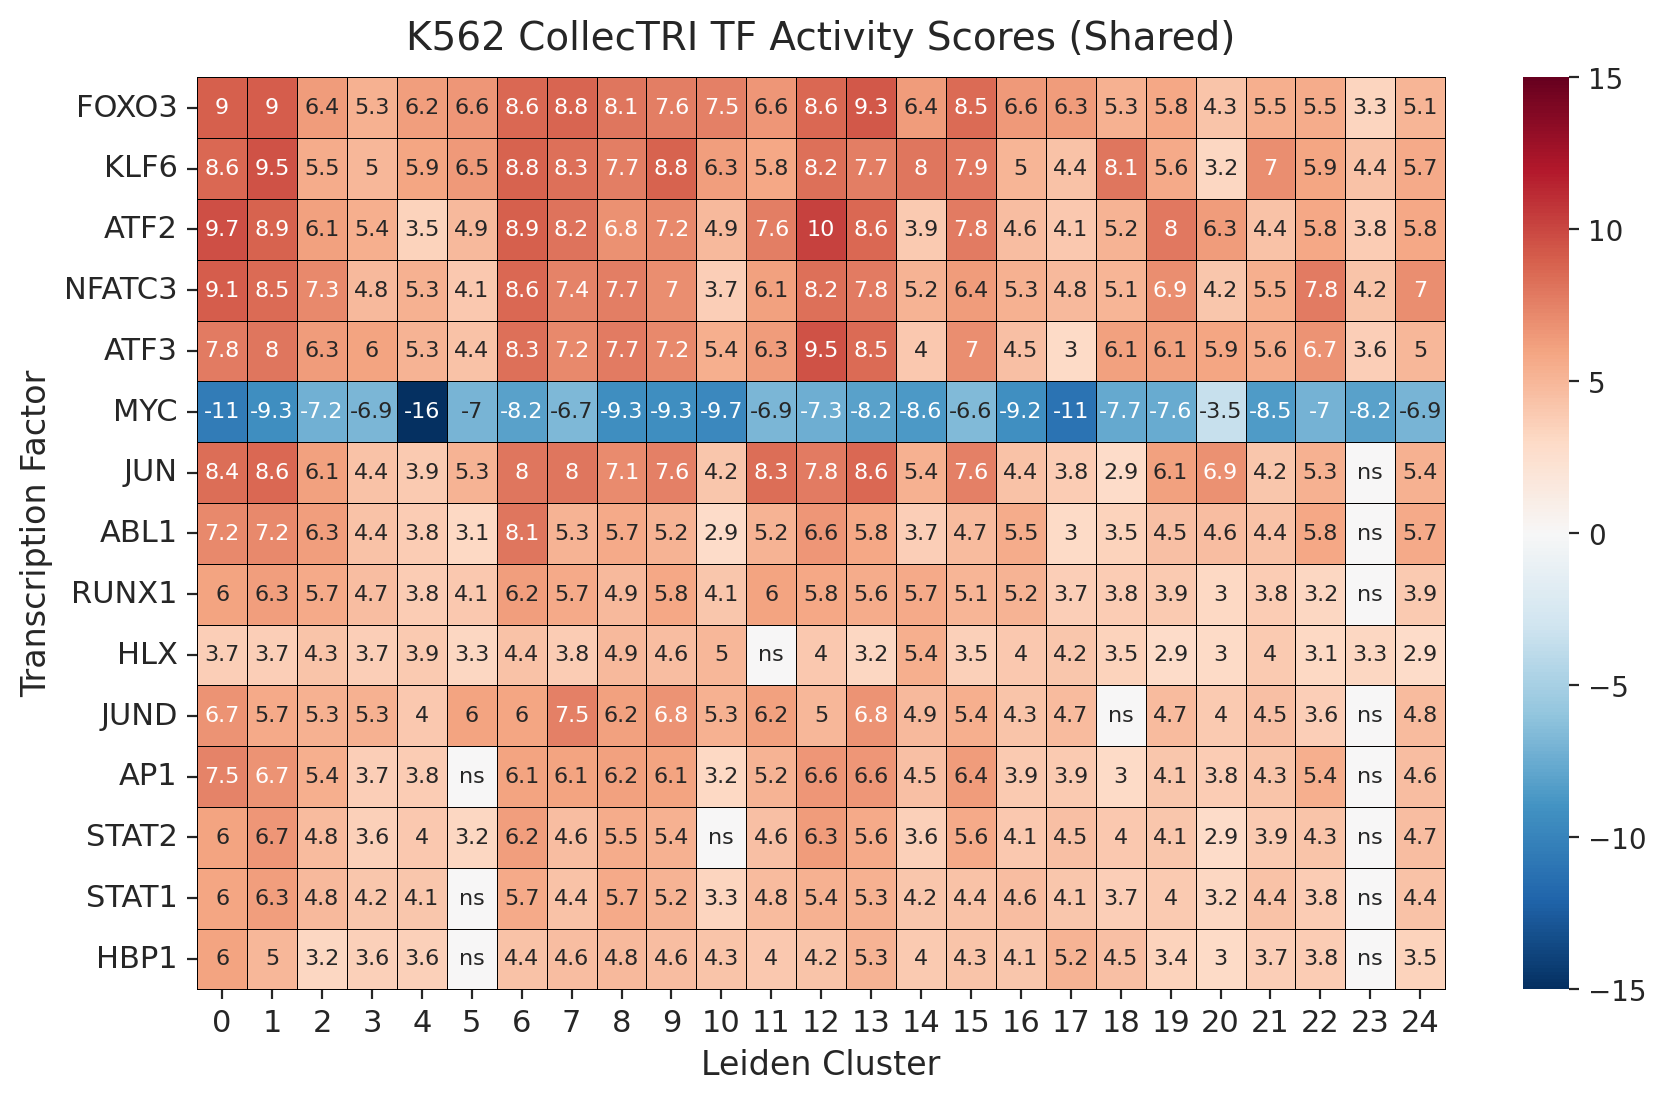

In [97]:
plot_tf_pw_activity_heatmap(tf_acts_df_k562_shared_23, title="K562 CollecTRI TF Activity Scores (Shared)",
                            xlabel="Leiden Cluster", ylabel="Transcription Factor", figsize=(10,6),
                            vmin=-15, vmax=15)

### Pathways

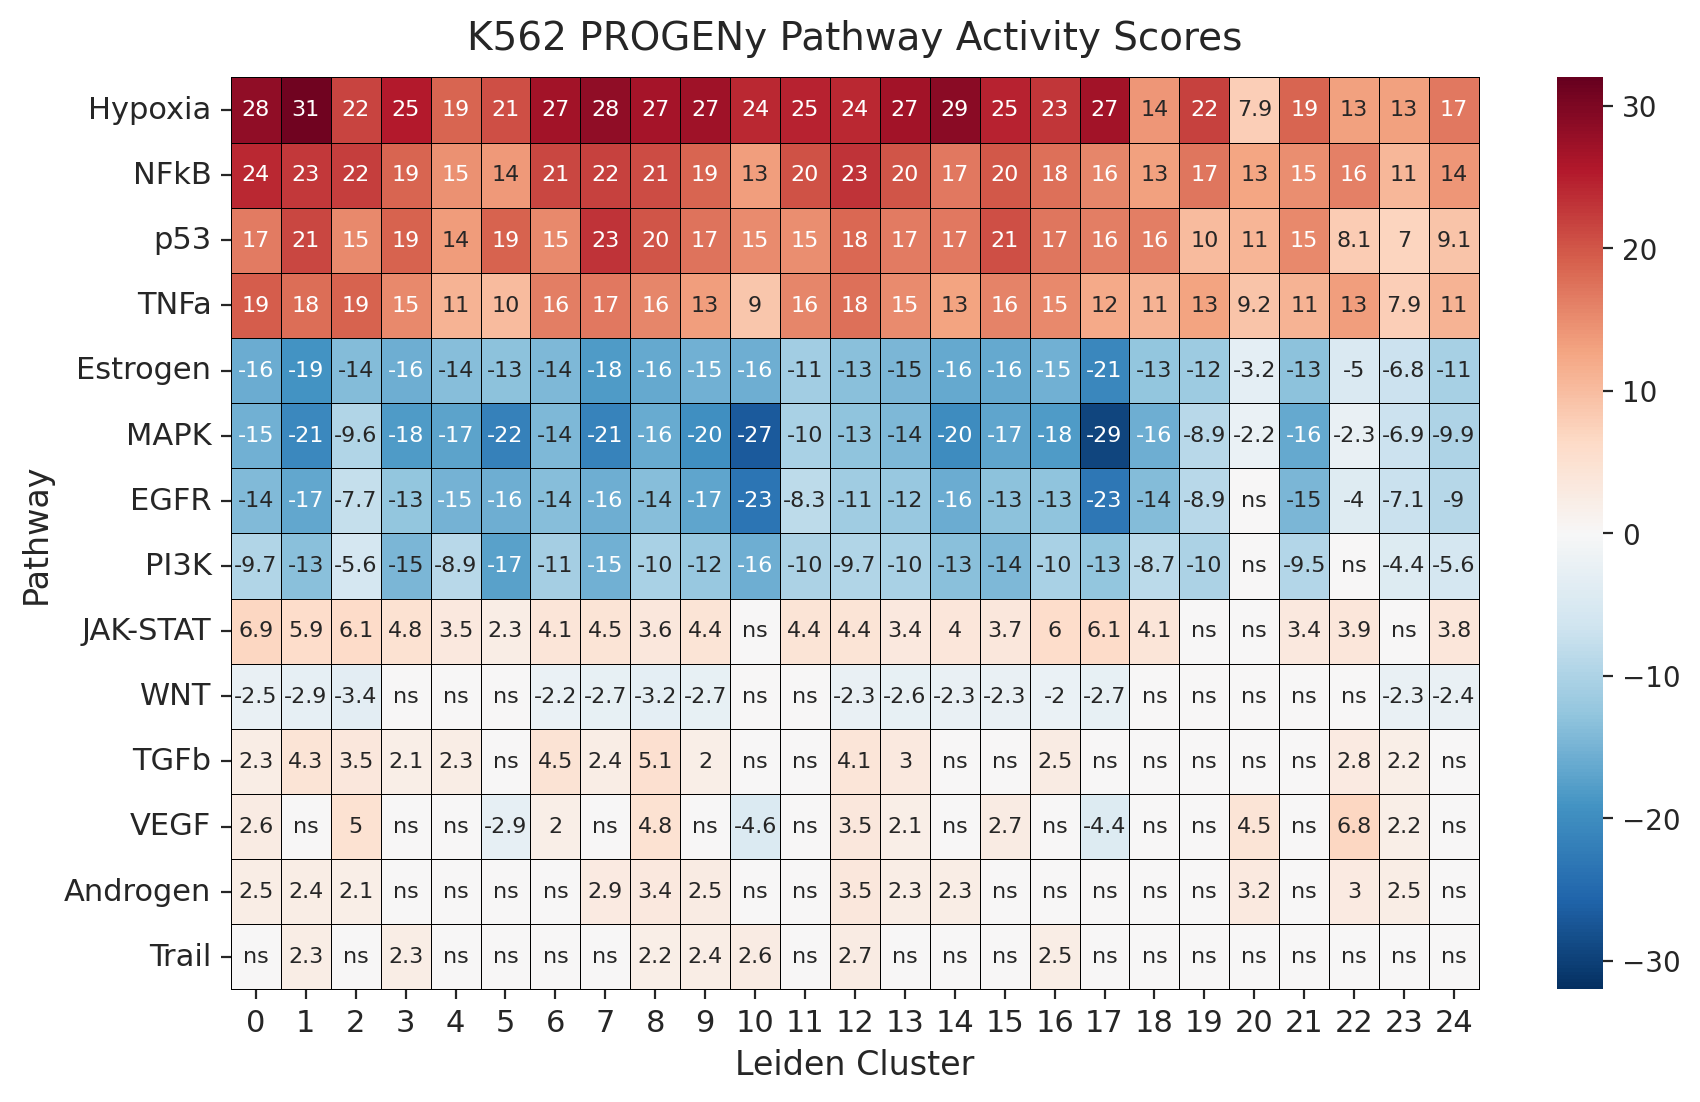

In [96]:
plot_tf_pw_activity_heatmap(pw_acts_df_k562, title="K562 PROGENy Pathway Activity Scores",
                            xlabel="Leiden Cluster", ylabel="Pathway", figsize=(10,6),
                            show_numeric_labels=True)